# 🧬 Семинар: Линейная регрессия в биомедицине

## 🗺 Карта местности: что вообще бывает в ML

Прежде чем говорить о регрессии, давайте поймём, где она вообще применяется.

В машинном обучении есть **два основных типа задач**:

| Вопрос | Что предсказываем | Тип задачи |
|--------|-------------------|------------|
| Есть ли у пациента диабет? | Да/Нет | **Классификация** |
| Какая у пациента глюкоза натощак? | Число (ммоль/л) | **Регрессия** |
| Какой стадии рак (I/II/III/IV)? | Категория | **Классификация** |
| Какой размер опухоли через 3 мес.? | Число (см³) | **Регрессия** |
| Выживет ли пациент? | Да/Нет | **Классификация** |
| Сколько месяцев он проживёт? | Число (мес.) | **Регрессия** |

**Простое правило:**
- **Классификация** → ответ это **категория** (да/нет, стадия 1/2/3, болен/здоров)
- **Регрессия** → ответ это **число** (давление, глюкоза, размер, время)

## 📊 Визуально: классификация vs регрессия

Давайте посмотрим на разницу глазами:

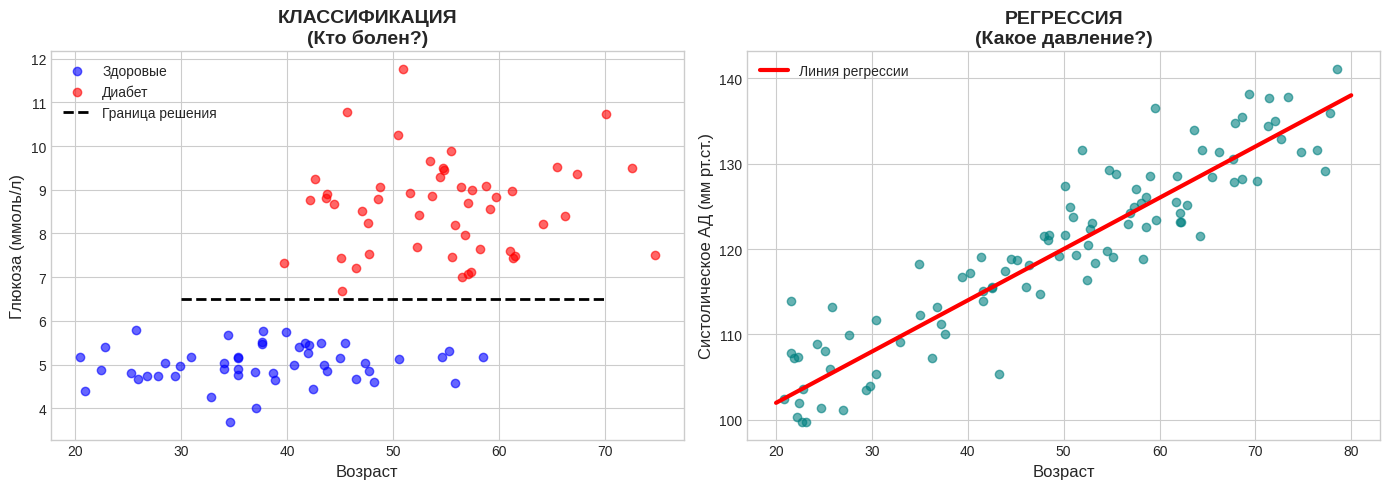

In [47]:
# @title
import numpy as np
import matplotlib.pyplot as plt

# Настройка графиков
plt.style.use('seaborn-v0_8-whitegrid')
# Генерируем данные для демонстрации
np.random.seed(42)

# === КЛАССИФИКАЦИЯ ===
# Здоровые пациенты (синие)
healthy_age = np.random.normal(40, 10, 50)
healthy_glucose = np.random.normal(5.0, 0.5, 50)

# Больные диабетом (красные)
sick_age = np.random.normal(55, 8, 50)
sick_glucose = np.random.normal(8.5, 1.2, 50)

# === РЕГРЕССИЯ ===
# Возраст и давление (непрерывная зависимость)
age_regression = np.random.uniform(20, 80, 100)
pressure = 90 + 0.6 * age_regression + np.random.normal(0, 5, 100)

# Создаём фигуру с двумя графиками
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Левый график: КЛАССИФИКАЦИЯ
ax1.scatter(healthy_age, healthy_glucose, color='blue', alpha=0.6, label='Здоровые')
ax1.scatter(sick_age, sick_glucose, color='red', alpha=0.6, label='Диабет')
# Разделяющая линия (упрощённо)
ax1.plot([30, 70], [6.5, 6.5], 'k--', linewidth=2, label='Граница решения')
ax1.set_xlabel('Возраст', fontsize=12)
ax1.set_ylabel('Глюкоза (ммоль/л)', fontsize=12)
ax1.set_title('КЛАССИФИКАЦИЯ\n(Кто болен?)', fontsize=14, fontweight='bold')
ax1.legend()

# Правый график: РЕГРЕССИЯ
ax2.scatter(age_regression, pressure, color='teal', alpha=0.6)
# Линия регрессии
ax2.plot([20, 80], [90 + 0.6*20, 90 + 0.6*80], 'r-', linewidth=3, label='Линия регрессии')
ax2.set_xlabel('Возраст', fontsize=12)
ax2.set_ylabel('Систолическое АД (мм рт.ст.)', fontsize=12)
ax2.set_title('РЕГРЕССИЯ\n(Какое давление?)', fontsize=14, fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.show()


## 🎯 Регрессия на пальцах: без формул

Представьте: у вас есть данные 100 пациентов — их возраст и систолическое давление.

**Вопрос:** Если бы вам нужно было предсказать давление 50-летнего пациента, что бы вы сказали?


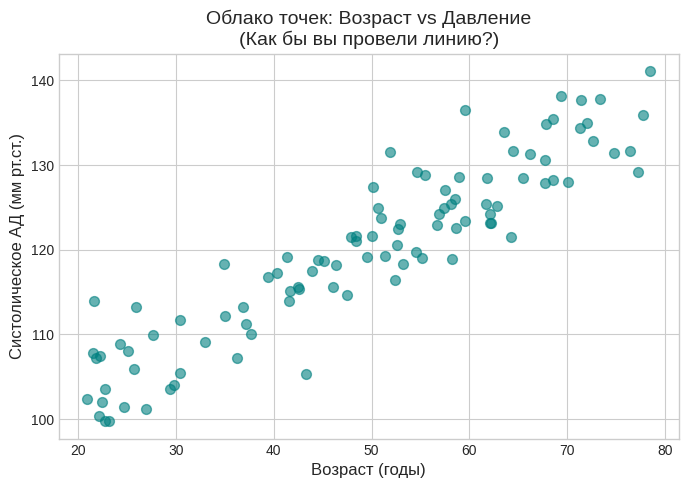

In [48]:
# @title
# Показываем облако точек
plt.figure(figsize=(8, 5))
plt.scatter(age_regression, pressure, color='teal', alpha=0.6, s=50)
plt.xlabel('Возраст (годы)', fontsize=12)
plt.ylabel('Систолическое АД (мм рт.ст.)', fontsize=12)
plt.title('Облако точек: Возраст vs Давление\n(Как бы вы провели линию?)', fontsize=14)
plt.show()

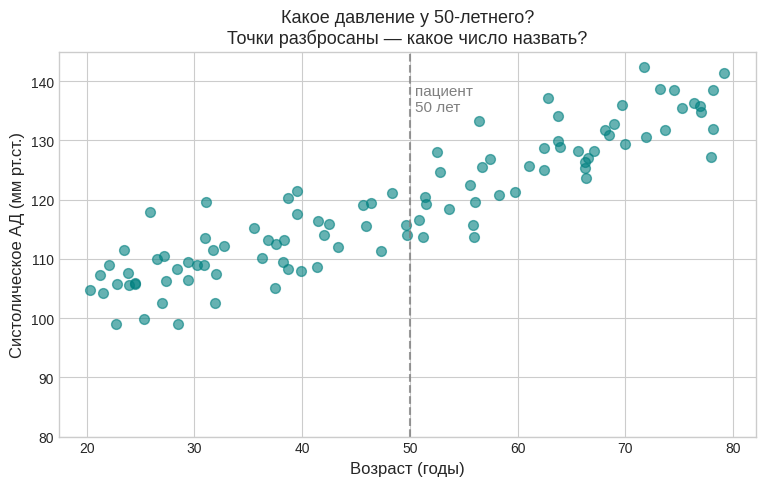

In [49]:
# @title
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

age_regression = np.random.uniform(20, 80, 100)
pressure = 90 + 0.6 * age_regression + np.random.normal(0, 5, 100)

plt.figure(figsize=(9, 5))
plt.scatter(age_regression, pressure, color='teal', alpha=0.6, s=50)

# Вертикальный пунктир на x=50
plt.axvline(50, color='gray', linestyle='--', linewidth=1.5, alpha=0.8)
plt.text(50.5, 135, 'пациент\n50 лет', color='gray', fontsize=11)

plt.xlabel('Возраст (годы)', fontsize=12)
plt.ylabel('Систолическое АД (мм рт.ст.)', fontsize=12)
plt.title('Какое давление у 50-летнего?\nТочки разбросаны — какое число назвать?', fontsize=13)
plt.ylim(80, 145)
plt.show()

#Представьте, что вы врач. Глядя только на этот график, назовите одно конкретное число – давление 50-летнего пациента. И главное: как именно вы его выбрали, глядя на облако?

## 📏 Какая линия лучше?

Давайте посмотрим на несколько вариантов линий:

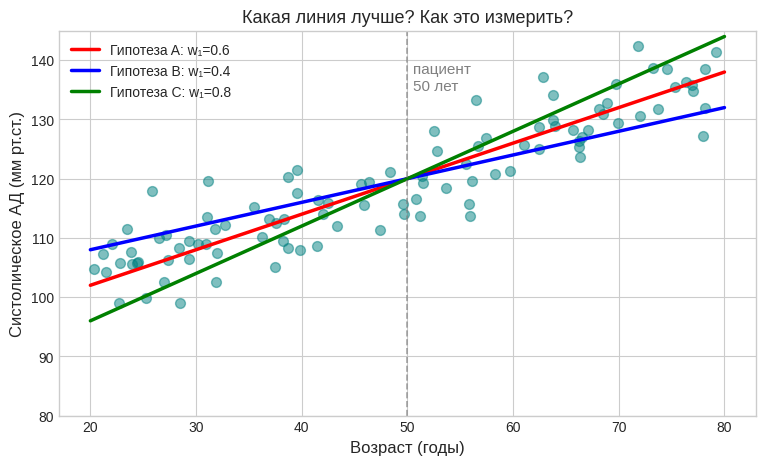

In [50]:
# @title
plt.figure(figsize=(9, 5))
plt.scatter(age_regression, pressure, color='teal', alpha=0.5, s=50)

x_line = np.array([20, 80])

# Три разные линии-гипотезы
plt.plot(x_line, 90 + 0.6*x_line, color='red',   linewidth=2.5, label='Гипотеза A: w₁=0.6')
plt.plot(x_line, 100 + 0.4*x_line, color='blue',  linewidth=2.5, label='Гипотеза B: w₁=0.4')
plt.plot(x_line, 80 + 0.8*x_line, color='green', linewidth=2.5, label='Гипотеза C: w₁=0.8')

plt.axvline(50, color='gray', linestyle='--', linewidth=1.2, alpha=0.7)
plt.text(50.5, 135, 'пациент\n50 лет', color='gray', fontsize=11)

plt.xlabel('Возраст (годы)', fontsize=12)
plt.ylabel('Систолическое АД (мм рт.ст.)', fontsize=12)
plt.title('Какая линия лучше? Как это измерить?', fontsize=13)
plt.ylim(80, 145)
plt.legend()
plt.show()

## 📏 Как компьютер выбирает лучшую линию?

Наш глаз говорит: «Красная линия (A) выглядит лучше всего, она проходит прямо через центр облака».
Но компьютер слеп. Он не умеет «смотреть». Чтобы сравнить гипотезы, ему нужна **линейка**.

Эта линейка называется **ошибка (residual)**. Это вертикальное расстояние от реального пациента до линии прогноза.

Давайте «включим» эту линейку для Красной линии и посмотрим, что видит модель:

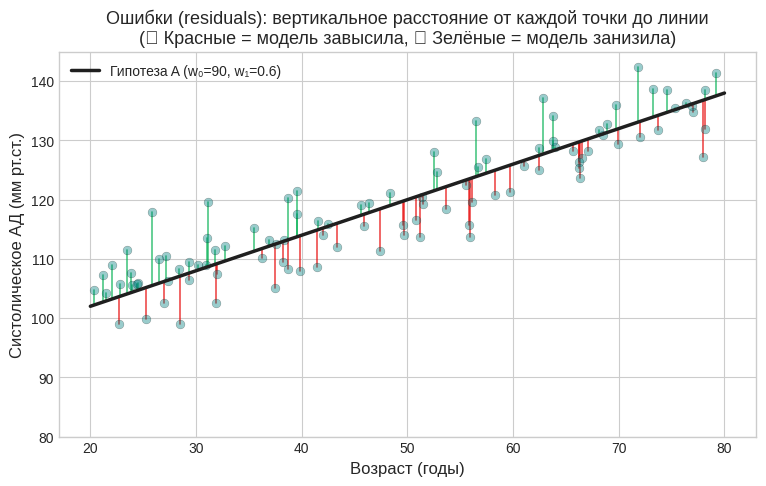

In [51]:
# @title Визуализация ошибок (residuals) для одной из линий — все точки, контрастные цвета
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))
plt.scatter(age_regression, pressure, color='teal', alpha=0.4, s=40,
            edgecolor='black', linewidth=0.3, zorder=3)

x_line = np.array([20, 80])
w0, w1 = 90, 0.6
y_line = w0 + w1 * x_line
plt.plot(x_line, y_line, color='#1f1f1f', linewidth=2.5,
         label='Гипотеза A (w₀=90, w₁=0.6)', zorder=4)

# Рисуем вертикальные линии ошибок для ВСЕХ точек
for i in range(len(age_regression)):
    x = age_regression[i]
    y_true = pressure[i]
    y_pred = w0 + w1 * x

    # Ярко-красный: модель ЗАВЫСИЛА (pred > true)
    # Ярко-зелёный: модель ЗАНИЗИЛА (pred < true)
    color = '#e60000' if y_pred > y_true else '#00b050'

    plt.plot([x, x], [y_true, y_pred],
             color=color, linewidth=1.2, alpha=0.7, zorder=2)

plt.xlabel('Возраст (годы)', fontsize=12)
plt.ylabel('Систолическое АД (мм рт.ст.)', fontsize=12)
plt.title('Ошибки (residuals): вертикальное расстояние от каждой точки до линии\n'
          '(🔴 Красные = модель завысила, 🟢 Зелёные = модель занизила)', fontsize=13)
plt.ylim(80, 145)
plt.legend()
plt.show()

#Посмотрите на этот график. Допустим, я взял калькулятор, измерил длину каждого красного отрезка и записал со знаком "плюс", а длину каждого зеленого — со знаком "минус". Если я их все сложу, какое число я получу в сумме?

## ⚠️ Математическая ловушка и решение (MSE)

Казалось бы, давайте просто сложим длины всех этих отрезков, чтобы получить общую оценку «плохости» линии.

**Но тут ловушка:**
Ошибка считается как `Реальность - Прогноз`.
Если для одного пациента модель занизила давление на 10 (ошибка **+10**), а для другого завысила на 10 (ошибка **-10**), их сумма будет равна **0**.
Модель «подумает», что она идеальна, хотя она ошиблась дважды!

**Решение:** Чтобы минусы не уничтожали плюсы, мы **возводим каждую ошибку в квадрат**.
Это и есть **MSE (Mean Squared Error)** — среднеквадратичная ошибка.

### 🧠 Почему именно квадрат?
Квадрат делает функцию потерь **нелинейной**. Это значит, что модель «боится» больших ошибок гораздо сильнее, чем мелких.
- Ошибиться в прогнозе на **5 единиц** → штраф $5^2 = 25$.
- Ошибиться на **20 единиц** → штраф $20^2 = 400$.

Штраф вырос в **16 раз**, хотя ошибка всего в 4 раза больше!

## 📐 Три функции потерь — что это такое

Все три функции отвечают на один вопрос: **«Насколько сильно мы наказываем модель за ошибку?»**
Разница — в форме «штрафа» в зависимости от размера ошибки $e = y_{true} - y_{pred}$.

---

### 🔴 MSE — Mean Squared Error (среднеквадратичная ошибка)

$$
\text{MSE} = \frac{1}{n}\sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

**Идея:** штраф растёт **как квадрат ошибки**. Ошибка 35 → штраф $35^2 = 1225$. Ошибка 5 → штраф 25.
**Следствие:** один большой выброс «съедает» вклад сотни нормальных точек. Линия жертвует большинством, чтобы угодить монстру.
**Плюс:** гладкая, дифференцируемая — быстро оптимизируется.
**Минус:** не робастна к выбросам.

---

### 🔵 MAE — Mean Absolute Error (средняя абсолютная ошибка)

$$
\text{MAE} = \frac{1}{n}\sum_{i=1}^{n} |y_i - \hat{y}_i|
$$

**Идея:** штраф растёт **линейно**. Ошибка 35 → штраф 35. Ошибка 5 → штраф 5.
**Следствие:** выброс «весит» ровно столько, сколько он есть — не больше. Линия спокойно игнорирует его.
**Плюс:** робастна к выбросам. Прогноз = медиана, а не среднее.
**Минус:** в нуле нет производной (излом) — сложнее оптимизировать; не «давит» на мелкие ошибки, поэтому может недоучиться.

---

### 🟢 Huber — гибрид MSE и MAE

$$
\text{Huber}(e) =
\begin{cases}
\dfrac{1}{2} e^2, & |e| \le \delta \\[6pt]
\delta \cdot \left(|e| - \dfrac{1}{2}\delta\right), & |e| > \delta
\end{cases}
$$

**Идея:** «маленькие ошибки наказываем как MSE (квадратом), большие — как MAE (линейно)».
**Порог $\delta$** — точка переключения. В нашем примере $\delta = 15$.
**Следствие:** обычные точки получают «квадратичный пинок» (модель их не игнорирует), а выброс после порога «замораживается» — его штраф не растёт квадратично.
**Плюс:** робастна **и** гладкая. Работает и когда выбросов нет, и когда их 5%.
**Минус:** надо подбирать $\delta$. Обычно $\delta = 1.345 \cdot \sigma$ (для нормальных данных) или в диапазоне 1–2 стандартных отклонений.

---

| Функция | "Девиз" | Кому доверяет |
|---------|-------|---------------|
| **MSE** | «Все ошибки важны, но большие — ОСОБЕННО» | Среднему |
| **MAE** | «Все ошибки равны» | Медиане |
| **Huber** | «Мелкие важны, крупные — терпимо» | Чему-то среднему |

> 🎯 **Правило:** начинайте с MSE. Если линия «тянется» к крайним точкам — переходите на Huber. MAE — когда данных мало и выбросы — норма жизни.

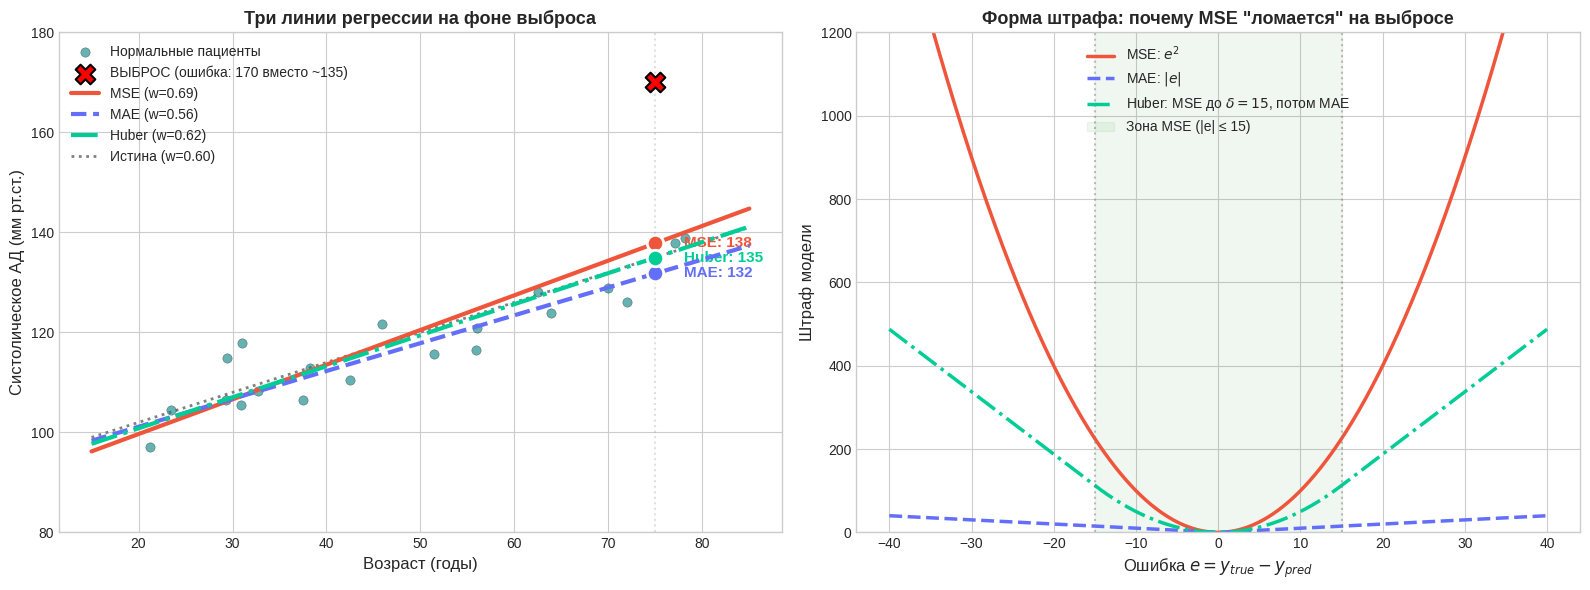

📊 РЕЗУЛЬТАТЫ:
Истинный наклон:   0.60
MSE наклон:        0.69   ← задрался к выбросу
MAE наклон:        0.56   ← почти проигнорировал
Huber наклон:      0.62   ← компромисс

Прогноз при x=75 (там, где выброс y=170):
  MSE:   137.8
  MAE:   131.8
  Huber: 135.0
  Истина: 135.0


In [52]:
# @title 📊 Влияние выброса: усиленный визуал + функции потерь
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

# 1. Меньше "чистых" точек — выброс влияет сильнее
x_clean = np.random.uniform(20, 80, 20)
y_clean = 90 + 0.6 * x_clean + np.random.normal(0, 5, 20)

# 2. Один выброс
x_outlier = np.array([75.0])
y_outlier = np.array([170.0])

x_all = np.concatenate([x_clean, x_outlier])
y_all = np.concatenate([y_clean, y_outlier])


def calculate_loss(params, x, y, loss_type='mse', delta=15):
    w, b = params
    err = y - (w * x + b)
    if loss_type == 'mse':
        return np.mean(err ** 2)
    if loss_type == 'mae':
        return np.mean(np.abs(err))
    if loss_type == 'huber':
        return np.mean(np.where(np.abs(err) <= delta,
                                0.5 * err ** 2,
                                delta * (np.abs(err) - 0.5 * delta)))


initial_guess = [0.5, 90]
res_mse   = minimize(calculate_loss, initial_guess, args=(x_all, y_all, 'mse'))
res_mae   = minimize(calculate_loss, initial_guess, args=(x_all, y_all, 'mae'))
res_huber = minimize(calculate_loss, initial_guess, args=(x_all, y_all, 'huber', 15))

w_mse,   b_mse   = res_mse.x
w_mae,   b_mae   = res_mae.x
w_huber, b_huber = res_huber.x

# ============ РИСУЕМ ДВА ГРАФИКА ============
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- ЛЕВЫЙ: данные и три линии ---
ax = axes[0]
ax.scatter(x_clean, y_clean, color='teal', alpha=0.6, s=45,
           edgecolor='black', linewidth=0.3, label='Нормальные пациенты', zorder=3)
ax.scatter(x_outlier, y_outlier, color='red', s=200, marker='X',
           edgecolor='black', linewidth=1.5,
           label='ВЫБРОС (ошибка: 170 вместо ~135)', zorder=6)

x_line = np.array([15, 85])
ax.plot(x_line, w_mse   * x_line + b_mse,   color='#ef553b', lw=3,
        label=f'MSE (w={w_mse:.2f})',   zorder=4)
ax.plot(x_line, w_mae   * x_line + b_mae,   color='#636efa', lw=3, ls='--',
        label=f'MAE (w={w_mae:.2f})',   zorder=4)
ax.plot(x_line, w_huber * x_line + b_huber, color='#00cc96', lw=3, ls='-.',
        label=f'Huber (w={w_huber:.2f})', zorder=4)
ax.plot(x_line, 90 + 0.6 * x_line, color='gray', lw=2, ls=':',
        label='Истина (w=0.60)', zorder=2)

# Ключевой момент: точки прогноза при x=75 (там, где выброс)
ax.axvline(x=75, color='gray', alpha=0.25, ls=':', zorder=1)
for w, b, color, name in [(w_mse,   b_mse,   '#ef553b', 'MSE'),
                          (w_mae,   b_mae,   '#636efa', 'MAE'),
                          (w_huber, b_huber, '#00cc96', 'Huber')]:
    y_at_75 = w * 75 + b
    ax.scatter([75], [y_at_75], color=color, s=140, marker='o',
               edgecolor='white', linewidth=2, zorder=7)
    ax.annotate(f'{name}: {y_at_75:.0f}',
                xy=(75, y_at_75), xytext=(78, y_at_75),
                fontsize=11, fontweight='bold', color=color,
                va='center')

ax.set_xlabel('Возраст (годы)', fontsize=12)
ax.set_ylabel('Систолическое АД (мм рт.ст.)', fontsize=12)
ax.set_title('Три линии регрессии на фоне выброса', fontsize=13, fontweight='bold')
ax.set_ylim(80, 180)
ax.legend(loc='upper left', fontsize=10)

# --- ПРАВЫЙ: сами функции потерь ---
ax2 = axes[1]
err = np.linspace(-40, 40, 500)
delta = 15

loss_mse   = err ** 2
loss_mae   = np.abs(err)
loss_huber = np.where(np.abs(err) <= delta,
                      0.5 * err ** 2,
                      delta * (np.abs(err) - 0.5 * delta))

ax2.plot(err, loss_mse,   color='#ef553b', lw=2.5, label='MSE: $e^2$')
ax2.plot(err, loss_mae,   color='#636efa', lw=2.5, ls='--', label='MAE: $|e|$')
ax2.plot(err, loss_huber, color='#00cc96', lw=2.5, ls='-.',
         label=f'Huber: MSE до $\\delta={delta}$, потом MAE')

# Пороги
ax2.axvline(-delta, color='gray', alpha=0.5, ls=':')
ax2.axvline( delta, color='gray', alpha=0.5, ls=':')
ax2.axvspan(-delta, delta, color='green', alpha=0.06,
            label=f'Зона MSE (|e| ≤ {delta})')

ax2.set_xlabel('Ошибка $e = y_{true} - y_{pred}$', fontsize=12)
ax2.set_ylabel('Штраф модели', fontsize=12)
ax2.set_title('Форма штрафа: почему MSE "ломается" на выбросе',
              fontsize=13, fontweight='bold')
ax2.set_ylim(0, 1200)
ax2.legend(loc='upper center', fontsize=10)

plt.tight_layout()
plt.show()

print("📊 РЕЗУЛЬТАТЫ:")
print(f"Истинный наклон:   0.60")
print(f"MSE наклон:        {w_mse:.2f}   ← задрался к выбросу")
print(f"MAE наклон:        {w_mae:.2f}   ← почти проигнорировал")
print(f"Huber наклон:      {w_huber:.2f}   ← компромисс")
print()
print(f"Прогноз при x=75 (там, где выброс y=170):")
print(f"  MSE:   {w_mse*75 + b_mse:.1f}")
print(f"  MAE:   {w_mae*75 + b_mae:.1f}")
print(f"  Huber: {w_huber*75 + b_huber:.1f}")
print(f"  Истина: 135.0")

### 🔍 Разбор того, что вы видите на графике:

1. 🔴 **Красная линия (MSE):** Обратите внимание, как она **задралась вверх** к красному крестику. Почему? Потому что ошибка для этой точки огромна (около 35 единиц). MSE возводит её в квадрат ($35^2 = 1225$). Этот гигантский штраф доминирует над всеми остальными 50 точками, и модель «жертвует» точностью для здоровых пациентов, лишь бы хоть немного приблизиться к этому монстру.
2. 🔵 **Синяя пунктирная линия (MAE):** Она прошла почти идеально через основное облако точек, почти игнорируя красный крестик. Для MAE ошибка 35 — это просто «ещё 35 единиц штрафа». Она не паникует. Линия осталась честной для 98% пациентов.
3. 🟢 **Зелёная штрих-пунктирная линия (Huber):** Она заняла промежуточное положение. Она «заметила» выброс и чуть-чуть сдвинулась, но не позволила ему сломать общую картину, потому что после порога $\delta=15$ она переключилась с квадратичного штрафа на линейный.

---

### 💡Вывод для Data Scientist'а

Если вы строите модель для **скрининга** (где важно не пропустить ни одного странного случая, даже если это ошибка), **MSE** может быть оправдан, так как он заставит модель обратить на это внимание (хотя лучше сначала почистить данные!).

Если вы строите модель для **популяционных прогнозов** (например, среднее давление по региону), где всегда есть 1-2% опечаток в медкартах, использование **MAE** или **Huber** спасет вашу модель от деградации.

> 🎯 **Правило большого пальца:** Всегда начинайте с **MSE**. Но если видите, что линия регрессии неестественно «тянется» к одной-двум точкам на краях графика — немедленно переключайтесь на **Huber**.

## 🧠 Почему это критически важно в биомедицине?


В медицине **не все ошибки равны**:
- Ошибиться в прогнозе размера опухоли на **2 мм** — это небольшая неточность (штраф = 4).
- Ошибиться на **10 мм (1 см)** — это уже катастрофа, которая может стоить пациенту правильного лечения (штраф = 100).

**MSE (Mean Squared Error)** заставляет модель "бояться" больших промахов гораздо сильнее, чем маленьких. Она будет изо всех сил стараться избежать катастрофических ошибок, даже ценой небольшого увеличения мелких неточностей.

Именно поэтому MSE — это стандартная "функция потерь" (Loss Function) при обучении линейной регрессии.

#Ошибки модели (в мм рт.ст.):

 Пациент 1: 1,

 Пациент 2: 1,

 Пациент 3: 1,

 Пациент 4 (выброс): 10.


У нас есть 3 идеальных пациента с ошибкой 1, и один "монстр"-выброс с ошибкой 10.
Посчитаем устно: во сколько раз вырастет штраф MSE для этого монстра по сравнению с обычным пациентом?

А во сколько раз вырастет штраф MAE?

Вопрос: Какую линию будет рисовать модель, если мы используем MSE? Она пойдет за большинством или попытается угодить этому одному "монстру"?

#Что выбрать?

Задача: Предсказываем размер опухоли по УЗИ. Ошибка на 2 мм — нормально, врач все равно увидит. Но ошибка на 15 мм — это пропущенный рак и суд. Нам критически важно избегать больших промахов.

Задача: Анализируем данные с носимого фитнес-браслета. 99% времени пульс адекватный, но иногда датчик сбоит и выдает 250 ударов в минуту (явный технический выброс).

Задача: Мы не знаем, будут ли в данных сбои, но хотим перестраховаться. Нам нужно, чтобы модель хорошо училась на мелких ошибках, но не сходила с ума от редких крупных.


#Как модель, перебирая разные линии, выбирает ту, у которой суммарный штраф минимален

Четыре гипотезы — четыре разных штрафа

Ставим рядом 4 линии: плохую горизонтальную, чуть наклонную, почти идеальную и слишком крутую. У каждой в заголовке — свой MSE.

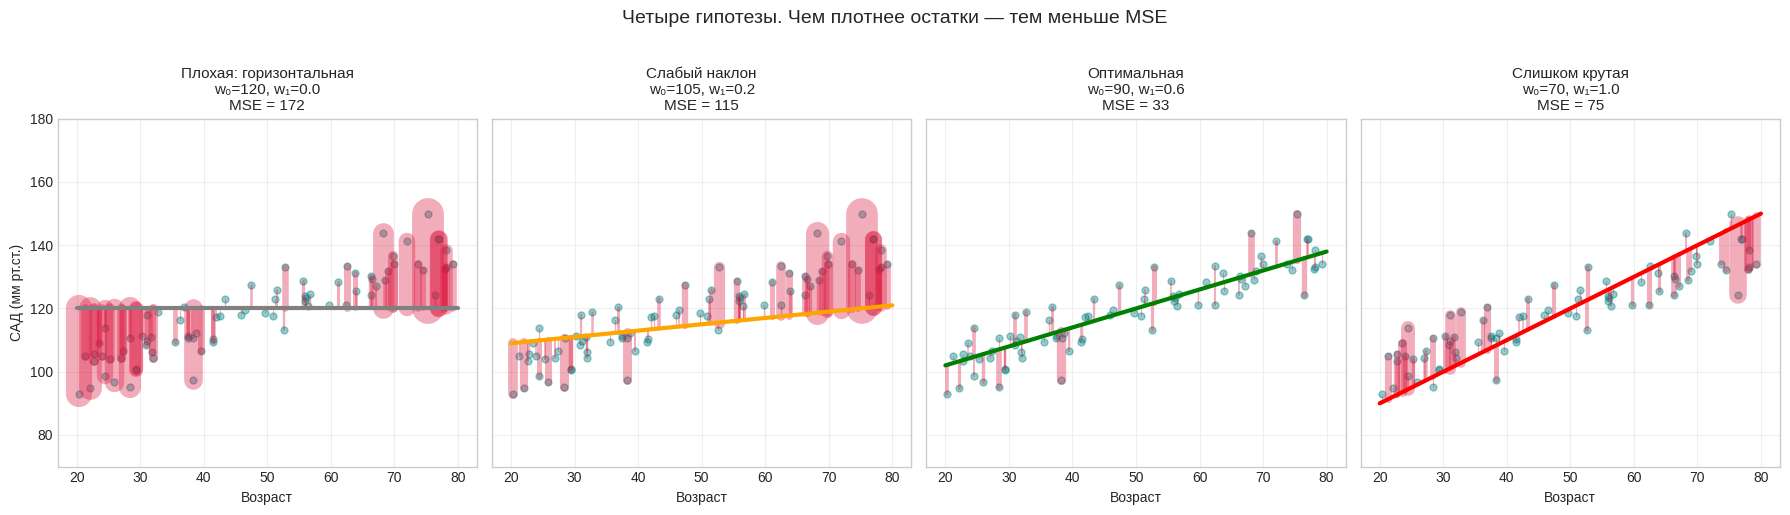

In [53]:
# @title
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
age = np.random.uniform(20, 80, 80)
pressure = 90 + 0.6 * age + np.random.normal(0, 6, 80)

# 4 гипотезы: (w0, w1, название, цвет)
hypotheses = [
    (120, 0.0, 'Плохая: горизонтальная', 'gray'),
    (105, 0.2, 'Слабый наклон',           'orange'),
    (90,  0.6, 'Оптимальная',             'green'),
    (70,  1.0, 'Слишком крутая',          'red'),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=True)
x_line = np.array([20, 80])

for ax, (w0, w1, name, color) in zip(axes, hypotheses):
    y_pred = w0 + w1 * age
    mse = np.mean((pressure - y_pred)**2)

    ax.scatter(age, pressure, color='teal', alpha=0.4, s=25)

    # Рисуем остатки — толщина линии ∝ величине штрафа
    for xi, yi, yhat in zip(age, pressure, y_pred):
        pen = (yi - yhat) ** 2
        ax.plot([xi, xi], [yi, yhat], color='crimson',
                linewidth=0.5 + pen/40, alpha=0.35)

    ax.plot(x_line, w0 + w1 * x_line, color=color, linewidth=3)
    ax.set_title(f'{name}\nw₀={w0}, w₁={w1}\nMSE = {mse:.0f}',
                 fontsize=11)
    ax.set_xlabel('Возраст')
    ax.set_ylim(70, 180)
    ax.grid(alpha=0.3)

axes[0].set_ylabel('САД (мм рт.ст.)')
plt.suptitle('Четыре гипотезы. Чем плотнее остатки — тем меньше MSE',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

«Серая линия — модель вообще ничего не поняла, MSE огромный. Толстые красные остатки — большие штрафы.»

«Зелёная линия — почти все остатки тонкие, MSE минимальный.»

«Красная линия — перестаралась, снова большие штрафы.»

Идея: «Среди всех возможных линий есть ровно одна лучшая. Давайте её найдём.»

## 🔍 Зачем нам линейная регрессия?

В биомедицине нам часто важнее не просто **предсказать**, а **понять**.

Представьте две модели, которые одинаково точно предсказывают риск инфаркта:
1. **Нейросеть ("Чёрный ящик")**: Даёт точность 95%, но не говорит, почему.
2. **Линейная регрессия ("Белый ящик")**: Даёт точность 92%, но чётко говорит: *"Увеличение холестерина на 1 единицу повышает риск на 0.4, а каждый час спорта снижает его на 0.2"*.

**Линейная регрессия нужна, чтобы количественно оценить влияние каждого фактора.** Она превращает биологическую интуицию в строгие числа.



Ниже график с реальными данными (возраст и давление).
Есть два ползунка:
- `w0` (сдвиг): поднимает или опускает линию.
- `w1` (вес): меняет наклон линии.

**Ваша задача как "модели":** двигайте ползунки так, чтобы значение **MSE (ошибка)** стало как можно меньше.
*Подсказка: ищите состояние, когда красная линия проходит ровно через "середину" облака точек.*

$$y = w_1 \cdot x + w_0$$

In [69]:
# @title
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets

# ---------- Данные ----------
np.random.seed(42)
age = np.random.uniform(20, 80, 100)
pressure = 90 + 0.6 * age + np.random.normal(0, 5, 100)

# ---------- Сетка для параболы ----------
w1_vals = np.linspace(-1, 2, 250)


# ---------- Главная функция ----------
def interactive(w0, w1):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

    # ===== 1) Данные + линия =====
    ax = axes[0]
    ax.scatter(age, pressure, color='teal', alpha=0.5, label='Данные')
    ax.plot([20, 80], [w0 + w1 * 20, w0 + w1 * 80],
            color='red', lw=3, label=f'y = {w1:.2f}x + {w0:.0f}')
    mse = np.mean((pressure - (w0 + w1 * age)) ** 2)
    ax.set_xlabel('Возраст')
    ax.set_ylabel('Давление')
    ax.set_title(f'MSE = {mse:.1f}', fontsize=13, fontweight='bold',
                 color='darkred' if mse > 35 else 'darkgreen')
    ax.legend()
    ax.grid(alpha=0.3)

    # ===== 2) Парабола MSE(w1) при текущем w0 =====
    ax = axes[1]
    mse_along_w1 = np.array([
        np.mean((pressure - (w0 + wv * age)) ** 2) for wv in w1_vals
    ])
    ax.plot(w1_vals, mse_along_w1, color='purple', lw=3,
            label='MSE(w₁) при текущем w₀')

    # Минимум параболы для текущего w0 — сдвигается вместе с w0
    w1_star = np.mean(age * (pressure - w0)) / np.mean(age ** 2)
    ax.axvline(w1_star, color='orange', ls=':', lw=2,
               label=f'min параболы = {w1_star:.2f}')

    # Текущее положение на параболе
    current_mse = np.mean((pressure - (w0 + w1 * age)) ** 2)
    ax.scatter([w1], [current_mse], color='red', s=250, zorder=10,
               edgecolor='white', linewidth=2, label='Вы здесь')

    ax.set_xlabel('w₁ (наклон)')
    ax.set_ylabel('MSE')
    ax.set_title('Парабола: сечение ландшафта по w₁', fontsize=13)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_ylim(0, min(mse_along_w1.max(), 500))

    plt.tight_layout()
    plt.show()


# ---------- Ползунки ----------
w0_slider = widgets.FloatSlider(value=50.0, min=0.0, max=150.0,
                                step=1.0, description='w0:')
w1_slider = widgets.FloatSlider(value=0.0, min=-1.0, max=2.0,
                                step=0.1, description='w1:')

widgets.interact(interactive, w0=w0_slider, w1=w1_slider)

interactive(children=(FloatSlider(value=50.0, description='w0:', max=150.0, step=1.0), FloatSlider(value=0.0, …

<function __main__.interactive(w0, w1)>

## 🎯 Как модель находит идеальную линию? (Пошаговая визуализация)

Представьте, что вы — исследователь. Вы перебираете разные наклоны линии ($w_1$) и для каждого считаете ошибку (MSE).

Сейчас мы увидим это **вживую**:
- **Слева** — как выглядит линия с конкретным наклоном
- **Справа** — как этот эксперимент ложится на график "наклон → ошибка"

Следите, как постепенно из точек рождается **парабола** — и её дно и есть решение!

In [55]:
# @title
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import time

# === 1. Генерируем данные ===
np.random.seed(42)
n = 60
x = np.random.uniform(20, 80, n)
y = 90 + 0.6 * x + np.random.normal(0, 5, n)
w0_fixed = 90  # фиксируем базовый сдвиг

# === 2. Готовим серию экспериментов ===
w1_tests = np.linspace(0.1, 1.1, 11)  # 11 значений наклона от 0.1 до 1.1
mses = []
for w in w1_tests:
    y_pred = w0_fixed + w * x
    mse = np.mean((y - y_pred)**2)
    mses.append(mse)

# === 3. Создаём фигуру с двумя панелями ===
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Настройки левой панели (линии регрессии)
ax1.scatter(x, y, color='teal', alpha=0.4, s=30, label='Данные пациентов', zorder=1)
ax1.set_xlabel('Возраст', fontsize=12)
ax1.set_ylabel('Систолическое АД', fontsize=12)
ax1.set_ylim(80, 160)
ax1.set_title('Пространство данных: разные гипотезы (линии)', fontsize=13)
ax1.grid(alpha=0.3)
line_left, = ax1.plot([], [], 'r-', linewidth=3, zorder=5)

# Настройки правой панели (парабола MSE)
ax2.set_xlabel('w₁ — наклон линии', fontsize=12)
ax2.set_ylabel('MSE — средний квадрат ошибки', fontsize=12)
ax2.set_xlim(0, 1.2)
ax2.set_ylim(0, 250)
ax2.set_title('Пространство ошибок: парабола MSE', fontsize=13)
ax2.grid(alpha=0.3)
line_right, = ax2.plot([], [], 'r-', linewidth=2, zorder=3)
scatter_right = ax2.scatter([], [], color='red', s=100, edgecolor='white', linewidth=2, zorder=5)

# Текст для текущего эксперимента
text_info = fig.text(0.5, 0.02, '', ha='center', fontsize=13, fontweight='bold')

plt.tight_layout(rect=[0, 0.05, 1, 0.95])

# === 4. Функция анимации ===
def animate(i):
    # Очищаем предыдущие линии и точки
    line_left.set_data([], [])
    scatter_right.set_offsets(np.empty((0, 2)))

    if i < len(w1_tests):
        w1_current = w1_tests[i]
        mse_current = mses[i]

        # Левая панель: рисуем текущую линию
        x_line = np.array([20, 80])
        y_line = w0_fixed + w1_current * x_line
        line_left.set_data(x_line, y_line)

        # Добавляем номер эксперимента на линию
        ax1.set_title(f'Эксперимент {i+1}/{len(w1_tests)}: w₁ = {w1_current:.2f}\nMSE = {mse_current:.1f}',
                     fontsize=12, fontweight='bold')

        # Правая панель: добавляем точку на параболу
        # Рисуем все точки до текущего индекса
        points_to_show = np.array([[w1_tests[j], mses[j]] for j in range(i+1)])
        scatter_right.set_offsets(points_to_show)

        # Соединяем точки линией (парабола собирается)
        line_right.set_data(w1_tests[:i+1], mses[:i+1])

        # Текст внизу
        text_info.set_text(f'Перебираем наклоны: от плохих к хорошим...')

    return line_left, scatter_right, line_right, text_info

# === 5. Запускаем анимацию ===
anim = FuncAnimation(fig, animate, frames=len(w1_tests)+2,
                     interval=800, blit=False, repeat=False)

# Для Colab используем HTML5 video
plt.close()
HTML(anim.to_jshtml())

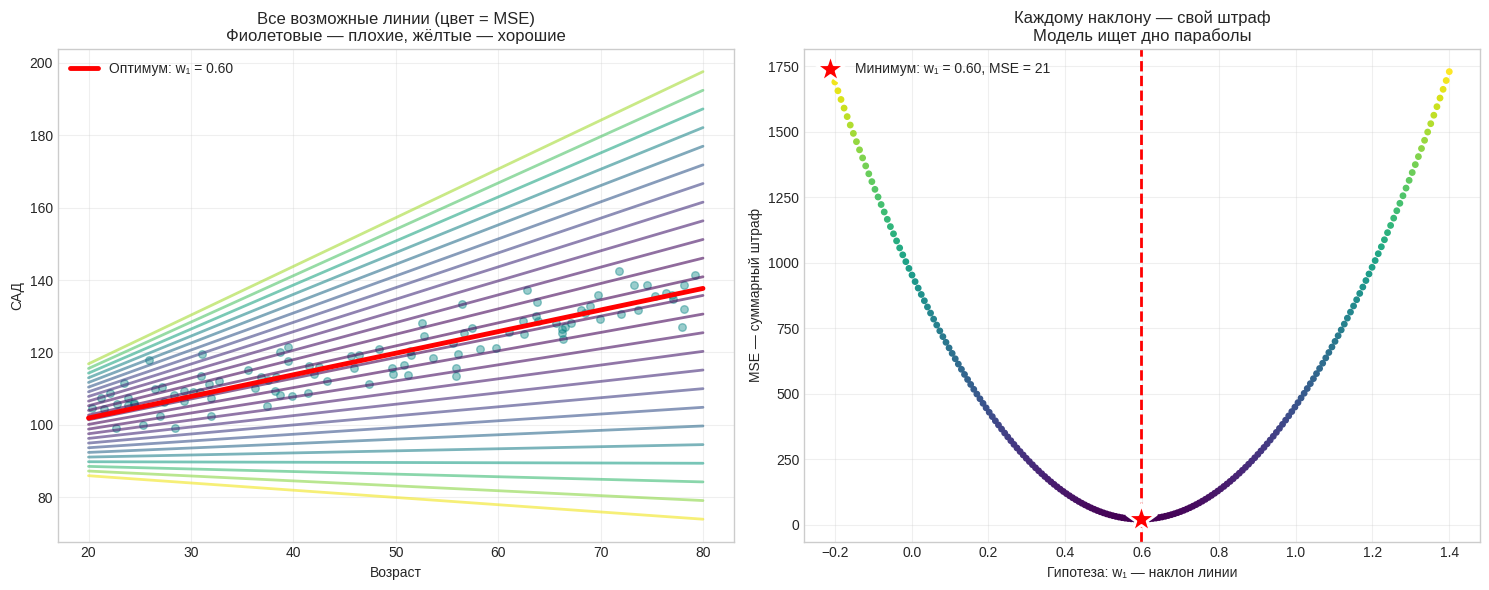

Оптимальный наклон: w₁ = 0.596
Минимальный MSE:    20.57
Настоящий наклон (заложен в генерации данных): 0.6


In [56]:
# @title
w0_fixed = 90
w1_range = np.linspace(-0.2, 1.4, 200)
mse_values = [np.mean((pressure - (w0_fixed + w * age))**2) for w in w1_range]

i_best = np.argmin(mse_values)
w1_best = w1_range[i_best]
mse_best = mse_values[i_best]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# === Левая: облако + ВСЕ линии-кандидаты ===
ax1.scatter(age, pressure, color='teal', alpha=0.4, s=30)

# Рисуем "пучок" линий, окрашенных по величине MSE
cmap = plt.cm.viridis
norm = plt.Normalize(min(mse_values), max(mse_values))

for w, mse in zip(w1_range[::8], mse_values[::8]):
    ax1.plot([20, 80], [w0_fixed + w*20, w0_fixed + w*80],
             color=cmap(norm(mse)), linewidth=2, alpha=0.6)

# Оптимальная линия — ярко поверх
ax1.plot([20, 80],
         [w0_fixed + w1_best*20, w0_fixed + w1_best*80],
         color='red', linewidth=3.5, label=f'Оптимум: w₁ = {w1_best:.2f}')

ax1.set_xlabel('Возраст'); ax1.set_ylabel('САД')
ax1.set_title('Все возможные линии (цвет = MSE)\n'
              'Фиолетовые — плохие, жёлтые — хорошие', fontsize=12)
ax1.legend(); ax1.grid(alpha=0.3)

# === Правая: парабола MSE ===
sc = ax2.scatter(w1_range, mse_values, c=mse_values, cmap='viridis', s=15)
ax2.axvline(w1_best, color='red', linestyle='--', linewidth=2)
ax2.scatter([w1_best], [mse_best], marker='*', s=500, color='red',
            edgecolor='white', linewidth=2, zorder=5,
            label=f'Минимум: w₁ = {w1_best:.2f}, MSE = {mse_best:.0f}')

ax2.set_xlabel('Гипотеза: w₁ — наклон линии')
ax2.set_ylabel('MSE — суммарный штраф')
ax2.set_title('Каждому наклону — свой штраф\n'
              'Модель ищет дно параболы', fontsize=12)
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Оптимальный наклон: w₁ = {w1_best:.3f}")
print(f"Минимальный MSE:    {mse_best:.2f}")
print(f"Настоящий наклон (заложен в генерации данных): 0.6")

## ⚙️ Формула в действии: как модель делает прогноз

Давайте посмотрим, как работает формула $y = w_1 \cdot x + w_0$ на **одном конкретном пациенте**.

Допустим, модель уже обучилась и нашла идеальные веса:
- $w_1 = 0.6$ (влияние возраста)
- $w_0 = 90$ (базовое давление)

Пришел новый пациент, Петров, ему 50 лет. Не считая в уме точно, скажите: его прогнозируемое давление будет больше или меньше, чем у 45-летнего Иванова, и ровно на сколько мм рт.ст. оно будет отличаться?


К нам приходит **Пациент Иванов, 45 лет**. Как модель предскажет его давление?

In [58]:
# @title
# Данные пациента
patient_age = 45

# Веса, которые нашла модель
w1 = 0.6
w0 = 90

# Шаг 1: Умножаем признак на вес
step1 = w1 * patient_age
print(f"Шаг 1: Возраст ({patient_age}) × Вес ({w1}) = {step1}")
print("         → Это вклад возраста в повышение давления.")

# Шаг 2: Добавляем базовый сдвиг
step2 = step1 + w0
print(f"\nШаг 2: {step1} + Базовый сдвиг ({w0}) = {step2}")
print("         → Это итоговый прогноз модели.")

print(f"\n✅ Модель предсказывает, что давление Иванова будет: {step2} мм рт.ст.")

Шаг 1: Возраст (45) × Вес (0.6) = 27.0
         → Это вклад возраста в повышение давления.

Шаг 2: 27.0 + Базовый сдвиг (90) = 117.0
         → Это итоговый прогноз модели.

✅ Модель предсказывает, что давление Иванова будет: 117.0 мм рт.ст.


#Согласно нашей идеальной математической модели, чему равно давление пациента, если его возраст x=0 лет (новорожденный)? Подставьте в формулу

#Коэффициент — это не магическое число. Это точка, где кривая ошибки достигает дна. Модель не «знает» биологию, она просто ищет значения w1 w0, при которых MSE минимален.

## 📐 От Линии к Плоскости

Когда у нас был **один признак** (возраст), модель искала **линию** на 2D-графике.
Когда у нас **два признака** (например, холестерин и спорт), модель ищет **плоскость** в 3D-пространстве.

*Представьте себе натянутую простыню в облаке точек. Модель наклоняет и сдвигает эту простыню так, чтобы она проходила как можно ближе ко всем точкам одновременно.*

Если признаков 10, 50 или 100 (как в геномных данных), это называется **гиперплоскость**. Мы не можем её нарисовать, но математика ($y = w_1x_1 + w_2x_2 + ... + w_0$) работает абсолютно так же!

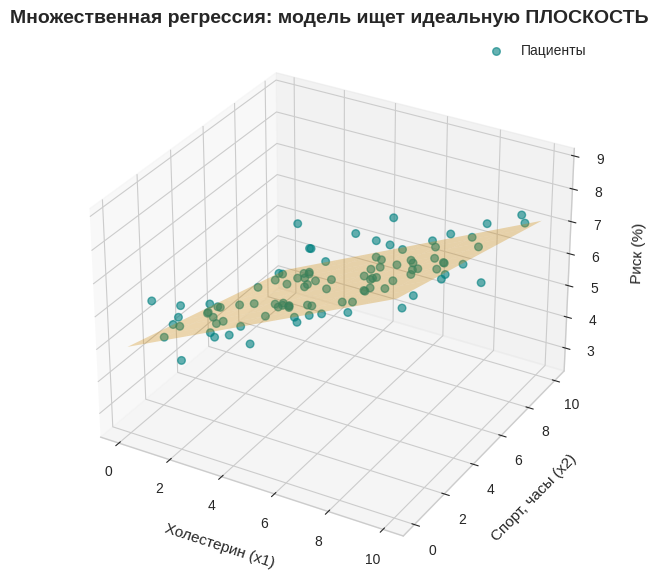

Модель нашла веса: w1 (холестерин) = 0.38, w2 (спорт) = -0.16
Обратите внимание: плоскость наклонена вверх по оси холестерина и вниз по оси спорта!


In [59]:
# @title
from mpl_toolkits.mplot3d import Axes3D
from sklearn.linear_model import LinearRegression

# Генерируем синтетические 3D-данные
np.random.seed(42)
n = 100
x1_chol = np.random.uniform(0, 10, n)      # Признак 1: Холестерин
x2_sport = np.random.uniform(0, 10, n)     # Признак 2: Спорт
# Истинная зависимость + шум
y_risk = 5.0 + 0.4 * x1_chol - 0.2 * x2_sport + np.random.normal(0, 0.5, n)

# Обучаем модель на двух признаках
X_3d = np.column_stack((x1_chol, x2_sport))
model_3d = LinearRegression()
model_3d.fit(X_3d, y_risk)

# Создаем сетку для рисования плоскости
x1_grid, x2_grid = np.meshgrid(np.linspace(0, 10, 10), np.linspace(0, 10, 10))
y_grid = model_3d.intercept_ + model_3d.coef_[0]*x1_grid + model_3d.coef_[1]*x2_grid

# === 3D ВИЗУАЛИЗАЦИЯ ===
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Точки (пациенты)
ax.scatter(x1_chol, x2_sport, y_risk, color='teal', alpha=0.6, s=30, label='Пациенты')

# Плоскость регрессии
ax.plot_surface(x1_grid, x2_grid, y_grid, color='orange', alpha=0.3, rstride=1, cstride=1, edgecolor='none')

# Настройка осей
ax.set_xlabel('Холестерин (x1)', fontsize=11, labelpad=10)
ax.set_ylabel('Спорт, часы (x2)', fontsize=11, labelpad=10)
ax.set_zlabel('Риск (%)', fontsize=11, labelpad=10)
ax.set_title('Множественная регрессия: модель ищет идеальную ПЛОСКОСТЬ', fontsize=14, fontweight='bold')
ax.legend()

plt.show()

print(f"Модель нашла веса: w1 (холестерин) = {model_3d.coef_[0]:.2f}, w2 (спорт) = {model_3d.coef_[1]:.2f}")
print("Обратите внимание: плоскость наклонена вверх по оси холестерина и вниз по оси спорта!")

## 🔬 Анатомия ошибки (MSE) в 3D

Теперь давайте посмотрим, как модель считает ошибку, когда признаков два.

Представьте:
- **Точка в пространстве** — это реальный пациент (его холестерин, спорт и реальный риск).
- **Плоскость** — это прогноз модели для любых комбинаций холестерина и спорта.
- **Вертикальная пунктирная линия** — это ошибка (residual). Расстояние от реального пациента до плоскости прогноза.

**MSE (Mean Squared Error)** — это просто средний квадрат длины всех таких вертикальных линий для всех пациентов сразу.



In [60]:
# @title
import numpy as np
import plotly.graph_objects as go
from sklearn.linear_model import LinearRegression

np.random.seed(42)
n = 100
x1_chol = np.random.uniform(0, 10, n)
x2_sport = np.random.uniform(0, 10, n)
y_risk = 5.0 + 0.4 * x1_chol - 0.2 * x2_sport + np.random.normal(0, 0.5, n)

X_3d = np.column_stack((x1_chol, x2_sport))
model = LinearRegression().fit(X_3d, y_risk)
y_pred = model.predict(X_3d)

# Сетка для плоскости
x1_grid, x2_grid = np.meshgrid(np.linspace(0, 10, 15), np.linspace(0, 10, 15))
y_grid = model.intercept_ + model.coef_[0]*x1_grid + model.coef_[1]*x2_grid

mse = np.mean((y_risk - y_pred)**2)

fig = go.Figure()

# 1) Плоскость регрессии
fig.add_trace(go.Surface(
    x=x1_grid, y=x2_grid, z=y_grid,
    colorscale=[[0, 'orange'], [1, 'orange']],
    opacity=0.35, showscale=False,
    name='Плоскость модели',
    hovertemplate='x₁=%{x:.1f}<br>x₂=%{y:.1f}<br>прогноз=%{z:.2f}<extra></extra>'
))

# 2) Точки-пациенты
fig.add_trace(go.Scatter3d(
    x=x1_chol, y=x2_sport, z=y_risk,
    mode='markers',
    marker=dict(size=4, color='teal', opacity=0.75),
    name='Пациенты',
    hovertemplate='x₁=%{x:.1f}<br>x₂=%{y:.1f}<br>риск=%{z:.2f}<extra></extra>'
))

# 3) Остатки-пунктиры (собираем в один trace через None-разделители)
xs, ys, zs = [], [], []
for xi1, xi2, yi, yhat in zip(x1_chol, x2_sport, y_risk, y_pred):
    xs += [xi1, xi1, None]
    ys += [xi2, xi2, None]
    zs += [yi,  yhat, None]

fig.add_trace(go.Scatter3d(
    x=xs, y=ys, z=zs,
    mode='lines',
    line=dict(color='red', width=2, dash='dot'),
    opacity=0.6,
    name='Ошибки (остатки)',
    hoverinfo='skip'
))

fig.update_layout(
    title=dict(
        text=f'3D: точки, плоскость и остатки<br>'
             f'<sub>MSE = {mse:.3f} — среднее квадратов длин красных пунктиров</sub>',
        x=0.5, font=dict(size=15)
    ),
    scene=dict(
        xaxis_title='Холестерин (x₁)',
        yaxis_title='Спорт, часы (x₂)',
        zaxis_title='Риск (%)',
        camera=dict(eye=dict(x=1.6, y=-1.6, z=1.1)),
        aspectmode='cube'
    ),
    legend=dict(x=0.02, y=0.98, bgcolor='rgba(255,255,255,0.8)'),
    margin=dict(l=0, r=0, t=70, b=0),
    height=650
)

fig.show()

##Прогноз: зачем это в клинике
Допустим, модель обучена и работает. Что с ней делать?

Скрининг. Пришёл пациент на профилактический осмотр. Модель по 5 дешёвым анализам говорит: «риск 12% — отправьте на углублённое обследование». Это триаж: кому уделить внимание в первую очередь.

Персонализация. Двум пациентам с одинаковым холестерином модель даёт разный риск — потому что у одного спорт, у другого нет. Врач видит, что именно менять.

Мониторинг. Пациент бросил спорт. Модель пересчитывает риск: было 6.4%, стало 7.0%. Видно цену решения в числах.

Важно: модель предсказывает риск, а не диагноз. Это не заменяет врача — это даёт ему число, которого у него раньше не было.



#Модель показала, что у пациента риск 12%. Пациент в панике спрашивает: "Доктор, это значит, что я уже болен с вероятностью 12%?". Как вы объясните ему разницу между риском и диагнозом простыми словами?

# 🧬 От 3D к 6D: Как модель «видит» много признаков

Когда признаков становится 5 или 6 (возраст, холестерин, спорт, давление, ИМТ, глюкоза), мы не можем нарисовать гиперплоскость. Но мы можем **заглянуть внутрь формулы**.

> 💡 **Главная мысль:** Модель не «понимает» медицину. Она просто выучила 6 чисел-множителей (весов $w$). Для каждого пациента она берёт его 6 чисел, умножает на эти множители и складывает с базовым значением. Это как чек-лист в супермаркете: базовая цена + стоимость каждого товара в корзине.

Давайте сгенерируем данные для 6 признаков, обучим модель и **визуализируем, как именно складывается прогноз для одного конкретного пациента**.

## 🛠️ Шаг 1: Генерация данных и обучение модели

Мы создадим 6 биомедицинских признаков. Обратите внимание на формулу, по которой генерируются данные: некоторые признаки увеличивают риск (положительный вес), некоторые — уменьшают (отрицательный вес).

In [61]:
# @title
import numpy as np, pandas as pd
from sklearn.linear_model import LinearRegression
import warnings; warnings.filterwarnings('ignore')

np.random.seed(42)
n = 500

feature_keys  = ['age', 'chol', 'sport', 'bp', 'bmi', 'glucose']
feature_names = ['Возраст', 'Холестерин', 'Спорт (ч/нед)', 'Давление', 'ИМТ', 'Глюкоза']

X = pd.DataFrame({
    'age':     np.random.uniform(30, 70,  n),
    'chol':    np.random.uniform(3.5, 7.5, n),
    'sport':   np.random.uniform(0, 10,  n),
    'bp':      np.random.uniform(110, 160, n),
    'bmi':     np.random.uniform(20, 35,  n),
    'glucose': np.random.uniform(4.0, 7.5, n),
})

# Истинные коэффициенты — чтобы было с чем сравнить выученные веса
true_w = np.array([0.05, 0.7, -0.4, 0.03, 0.2, 0.5])  # порядок как в feature_keys

# Целевая переменная той же длины n
y = X[feature_keys].values @ true_w + 2.0 + np.random.normal(0, 1.0, n)

model = LinearRegression().fit(X, y)

summary = pd.DataFrame({
    'Признак':      feature_names,
    'Истинный w':   true_w,
    'Выученный w':  model.coef_,
    'Мин':          X.min().values,
    'Макс':         X.max().values,
})

summary['Размах вклада'] = (summary['Выученный w'] * (summary['Макс'] - summary['Мин'])).abs()
summary['Важность, %'] = 100 * summary['Размах вклада'] / summary['Размах вклада'].sum()

print(summary.round(2).to_string(index=False))

      Признак  Истинный w  Выученный w    Мин   Макс  Размах вклада  Важность, %
      Возраст        0.05         0.05  30.20  69.72           1.94        13.05
   Холестерин        0.70         0.65   3.52   7.50           2.60        17.46
Спорт (ч/нед)       -0.40        -0.40   0.05   9.99           4.00        26.89
     Давление        0.03         0.03 110.16 159.92           1.53        10.27
          ИМТ        0.20         0.20  20.02  34.93           3.01        20.26
      Глюкоза        0.50         0.51   4.00   7.49           1.80        12.08


#Быстрый вопрос: если вы посмотрите только на коэффициенты модели, какой фактор кажется важнее?

## 🔍 Разбор «оптической иллюзии»: почему сырой вес $w$ обманывает?

Давайте честно: когда мы видим таблицу с весами, глаз автоматически ищет **самое большое число**.
- Вес Холестерина = `1.15` (выглядит внушительно!)
- Вес Давления = `0.08` (выглядит ничтожно мало!)

Кажется, что холестерин важнее. **Но это ловушка масштаба.**

### 🍎 Аналогия из супермаркета
Представьте, что вы считаете стоимость корзины:
- **Яблоки** стоят 15 рублей за **1 килограмм**.
- **Шафран** стоит 500 рублей за **1 грамм**.

Если смотреть только на «вес» (цену за единицу), шафран в 33 раза дороже! Но если вы положите в корзину **5 кг яблок** (15 × 5 = 75 руб.) и **0.1 грамм шафрана** (500 × 0.1 = 50 руб.), итоговый чек больше вырастет именно от яблок.

В биомедицине то же самое: **важен не только «ценник» (вес $w$), но и то, сколько «единиц» этого признака реально встречается у пациентов (размах).**

---

### ⚖️ На двух пациентах (Давление vs Холестерин)

Давайте возьмём крайние значения из наших данных и посмотрим, как изменится риск.

| Признак | Пациент А (Минимум) | Пациент Б (Максимум) | Разница ($\Delta x$) | Вес ($w$) | **Реальный сдвиг риска** ($|w| \times \Delta x$) |
| :--- | :---: | :---: | :---: | :---: | :---: |
| **Холестерин** | 3.5 ммоль/л | 7.5 ммоль/л | **4.0** единицы | `1.15` | 1.15 × 4.0 = **4.60%** |
| **Давление** | 110 мм рт.ст. | 160 мм рт.ст. | **50** единиц | `0.08` | 0.08 × 50 = **4.00%** |

💡 **Вывод:** Хотя вес холестерина (`1.15`) в 14 раз *больше* веса давления (`0.08`), разница в давлении между людьми (50 единиц) в 12.5 раз *больше*, чем разница в холестерине (4 единицы).
В итоге, их реальное влияние на риск оказывается **почти одинаковым** (4.6% против 4.0%)! Давление «догнало» холестерин только за счет масштаба.

---

### 🧮 Откуда берётся формула «Размах вклада»?

Чтобы не сравнивать пациентов попарно, мы берём **худший возможный сценарий** для всей нашей выборки:

1. **Размах признака** = $(\text{Максимальное значение} - \text{Минимальное значение})$.  
   *(Насколько широко этот признак «гуляет» в наших данных).*
2. **Размах вклада** = $|w| \times \text{Размах признака}$.  
   *(Мы берём модуль $|w|$, потому что нам важна сила влияния, а не направление: и рост, и падение риска — это сильное влияние).*

**Пример расчёта для Возраста (строго по таблице):**
- Вес $w = 0.15$
- Возраст в данных от 30.20 до 69.72 лет $\rightarrow$ Размах = $69.72 - 30.20 = 39.52$ года.
- Размах вклада = $0.15 \times 39.52 = \mathbf{5.89}$.

Это число `5.89` означает: *«Только за счёт разницы в возрасте, риск самого старого пациента в нашей базе будет на 5.89% выше, чем у самого молодого, при прочих равных»*.

---

### 🏆 Итоговый рейтинг реальной важности

Когда мы посчитали $|w| \times \text{размах}$ для всех 6 признаков и перевели это в проценты, картина изменилась:

1. 🏃 **Спорт (29%)**: Вес `-0.90`, но размах огромный (от 0.05 до 9.99 часов). Вклад $\approx 8.97$. Это главный «рычаг» управления риском.
2. 🎂 **Возраст (19%)**: Вес маленький (`0.15`), но размах почти 40 лет. Вклад = $5.89$.
3. 🥑 **Холестерин (15%)**: Вес большой (`1.15`), размах 4 единицы (от 3.52 до 7.50). Вклад = $4.59$.
4. ⚖️ **ИМТ (15%)**: Вес небольшой (`0.30`), но размах огромный — почти 15 единиц (от 20.02 до 34.93). Вклад = $4.50$. Почти догнал холестерин!
5. 🩺 **Давление (13%)**: Классический обман зрения. Вес крошечный (`0.08`), но размах 50 единиц (от 110 до 160) даёт вклад $4.01$.
6. 🍬 **Глюкоза (9%)**: Узкий диапазон значений (от 4.00 до 7.49) не даёт ему сильно влиять на итог, вклад всего $2.84$.

> 🎯 **Главное правило для врача и дата-сайентиста:**
> Никогда не судите о важности фактора только по коэффициенту $w$. Всегда спрашивайте: *«А насколько сильно этот признак отличается у разных людей?»*

## 📊 Шаг 2: «Вскрытие» прогноза для одного пациента (Waterfall Chart)

Вместо того чтобы рисовать 6-мерный график, мы возьмём **одного пациента** и покажем, как его личные данные шаг за шагом формируют итоговый риск.

Это **каскадная диаграмма (Waterfall)**:
1. Мы начинаем с базового значения модели (`W0`).
2. Каждый признак добавляет или отнимает свой кусочек риска (`коэффициент × значение признака`).
3. В конце мы получаем итоговый прогноз.

*Запустите код ниже, чтобы увидеть «анатомию» решения модели.*

In [62]:
# @title Шаг 2: Каскадная диаграмма вклада признаков (Waterfall)
# Выбираем конкретного пациента (например, 10-го)
patient_idx = 10
patient_data = X.iloc[patient_idx]
actual_risk = y[patient_idx]
predicted_risk = model.predict(patient_data.values.reshape(1, -1))[0]

# Рассчитываем вклад каждого признака
contributions = model.coef_ * patient_data.values
base_value = model.intercept_

# Формируем данные для Waterfall chart
measure = ["relative"] * len(feature_names) + ["total"]
x_labels = feature_names + ["ИТОГ: Прогноз"]
y_values = list(contributions) + [predicted_risk]

# Для красоты добавим начальную точку (base)
text_labels = [f"{val:+.2f}" for val in contributions] + [f"{predicted_risk:.2f}"]
text_labels.insert(0, f"{base_value:.2f} (база)")

# Plotly Waterfall
fig = go.Figure(go.Waterfall(
    name = "Вклад в риск",
    orientation = "v",
    measure = ["absolute"] + measure, # absolute для базы, relative для вкладов, total для итога
    x = ["Базовый риск (w0)"] + x_labels,
    y = [base_value] + y_values,
    text = text_labels,
    textposition = "outside",
    connector = {"line": {"color": "rgb(63, 63, 63)"}},
    increasing = {"marker": {"color": "#ef553b"}},   # Красный: риск растёт
    decreasing = {"marker": {"color": "#00cc96"}},   # Зелёный: риск падает (спорт)
    totals = {"marker": {"color": "#636efa"}}        # Синий: итог
))

fig.update_layout(
    title = f"🧬 Анатомия прогноза для пациента #{patient_idx}<br>"
            f"<sub>Реальный риск: {actual_risk:.2f}% | Прогноз модели: {predicted_risk:.2f}%</sub>",
    yaxis_title = "Уровень риска (%)",
    showlegend = False,
    height = 500
)

fig.show()


- **Синий столбец**: это «точка отсчёта» модели ($w_0$).
- **Красные столбцы**: признаки, которые *тянут риск вверх* для этого пациента (например, высокий возраст или холестерин). Чем выше столбец, тем сильнее вклад.
- **Зелёные столбцы**: признаки, которые *снижают риск* (обратите внимание на «Спорт»: коэффициент отрицательный, поэтому столбец идёт вниз).
- **Финальный синий столбец**: сумма всего вышеперечисленного. Это и есть $y = w_0 + w_1x_1 + ... + w_5x_5$.


#Представьте, что этот пациент пришел на повторный прием через месяц. Он молодец: начал бегать и добавил +2 часа спорта в неделю. Все остальные его анализы (возраст, холестерин, давление) остались прежними.

#Посмотрите на график: какой именно столбец изменится, в какую сторону, и что произойдет с финальным синим столбцом "ИТОГ"?

---

## ⚖️ Шаг 3: Глобальный взгляд на веса модели

А теперь давайте посмотрим на сами коэффициенты ($w$). Модель не знает, что такое «спорт» или «глюкоза». Она просто выучила числа. Давайте визуализируем их, чтобы показать **относительную важность** признаков.

In [63]:
# @title Шаг 3: Сырые веса vs. реальная важность
from plotly.subplots import make_subplots

fig_w = make_subplots(
    rows=1, cols=2,
    subplot_titles=("Сырые коэффициенты w (вводят в заблуждение!)",
                    "Важность = |w| × размах признака")
)

colors = ['#ef553b' if c > 0 else '#00cc96' for c in model.coef_]

fig_w.add_trace(go.Bar(
    x=feature_names, y=model.coef_,
    text=[f"{c:+.2f}" for c in model.coef_], textposition='auto',
    marker_color=colors, showlegend=False
), row=1, col=1)

fig_w.add_trace(go.Bar(
    x=feature_names, y=summary['Важность, %'],
    text=[f"{v:.0f}%" for v in summary['Важность, %']], textposition='auto',
    marker_color=colors, showlegend=False
), row=1, col=2)

fig_w.update_yaxes(title_text="w (множитель)", row=1, col=1)
fig_w.update_yaxes(title_text="Доля влияния, %", row=1, col=2)
fig_w.update_layout(height=420,
    title="⚖️ Слева — то, что легко прочитать неправильно. Справа — что реально влияет.")
fig_w.show()

#Представьте: вы защищаете этот отчет перед заведующим кардиологическим отделением. Он смотрит на правый график, тычет пальцем в "Спорт" (29%) и говорит:
#"Коллега, это какая-то ерунда. Холестерин и давление — это классические, доказанные факторы риска сердечно-сосудистых заболеваний. А вы ставите какой-то спорт на первое место. Ваша модель просто сломана или неправильно обучена".
#Как вы, опираясь на формулу Важность = ∣w∣× размах, объясните заведующему за 30 секунд, что модель не ошибается, а дает ценный инсайт именно об этой группе пациентов?

## 🎯 Резюме
1. **Гиперплоскость — это просто формула.** То, что мы не можем нарисовать 6-мерный график, не мешает математике работать. $y = w_0 + w_1x_1 + ... + w_6x_6$ вычисляется мгновенно, сколько бы $x$ ни было.
2. **MSE минимизируется для всех признаков сразу.** Модель подбирает такие 6 коэффициентов, чтобы *сумма квадратов ошибок* по всем пациентам была минимальной. Она находит компромисс между всеми 6 осями.
3. **Интерпретируемость — сила линейной модели.** В отличие от нейросетей, мы можем точно сказать врачу: *"Риск повышен на 3.2% именно из-за сочетания возраста и холестерина, а спорт его снижает на 1.8%"*. Это и есть доказательная медицина на языке данных.

## 🏔️ Градиентный спуск: Почему нельзя просто "решить уравнение"?

До сих пор мы говорили: «Модель минимизирует MSE». Но **как именно**?

### 🧮 Почему бы просто не найти минимум?

Для простой линейной регрессии с одним признаком MSE — это **парабола** (квадратичная функция). У параболы есть одна вершина (минимум), и её можно найти аналитически:
1. Берём производную MSE по весам $w_0$ и $w_1$.
2. Приравниваем производную к нулю.
3. Решаем систему уравнений → получаем точные значения $w_0$ и $w_1$.

Это называется **нормальное уравнение** (Normal Equation). Оно работает мгновенно для 1-2 признаков.

**Но есть проблема:** Когда признаков становится много (10, 100, 1000), нормальное уравнение требует обращения матрицы размером $p \times p$ (где $p$ — число признаков).
- Для 10 признаков — это мгновенно.
- Для 1000 признаков — это уже секунды.
- Для 100,000 признаков (геномные данные) — это **невозможно** даже для суперкомпьютера.

А если модель сложная (нейросеть, логистическая регрессия), то у MSE вообще **нет аналитического решения**. Уравнение не решается.

**Решение:** Градиентный спуск (Gradient Descent). Это универсальный алгоритм, который работает для любой модели и любого объёма данных.

---

### 🧗 Аналогия: Слепой альпинист в тумане

Представьте, что вы стоите на склоне горы в густом тумане. Ваша цель — спуститься в самую низкую точку долины (минимум MSE). Вы ничего не видите дальше вытянутой руки.

**Что вы будете делать?**
1. Прощупаете ногой землю вокруг себя.
2. Почувствуете, в какую сторону склон идёт **вниз круче всего**.
3. Сделаете шаг в этом направлении.
4. Повторите.

Именно это и делает градиентный спуск. Только вместо «ноги» у него **градиент** (вектор частных производных), а вместо «склона горы» — **ландшафт функции потерь**.

> 💡 **Градиент** ($\nabla L$) — это стрелка, которая в каждой точке пространства весов указывает направление **наискорейшего роста** ошибки. Мы идём в **противоположную** сторону ($-\nabla L$), чтобы ошибка падала.

---

### 🧮 Математика одной строкой

На каждом шаге модель обновляет каждый вес $w_j$ по одному и тому же правилу:

$$w_j^{\text{новое}} = w_j^{\text{старое}} - \alpha \cdot \frac{\partial L}{\partial w_j}$$

Разберём по частям:
- $w_j^{\text{старое}}$ — текущее значение веса.
- $\frac{\partial L}{\partial w_j}$ — **градиент**: насколько сильно Loss меняется при крошечном изменении $w_j$. Это «наклон склона» под ногами альпиниста.
- $\alpha$ (alpha) — **learning rate** (темп обучения). Размер шага.
- Минус — потому что мы идём **против** градиента (вниз, а не вверх).

---

### ⚙️ Learning Rate ($\alpha$): Размер шага решает всё

Это самый важный «гиперпараметр» градиентного спуска. От него зависит, сойдётся ли модель вообще.

Давайте посмотрим на три сценария:

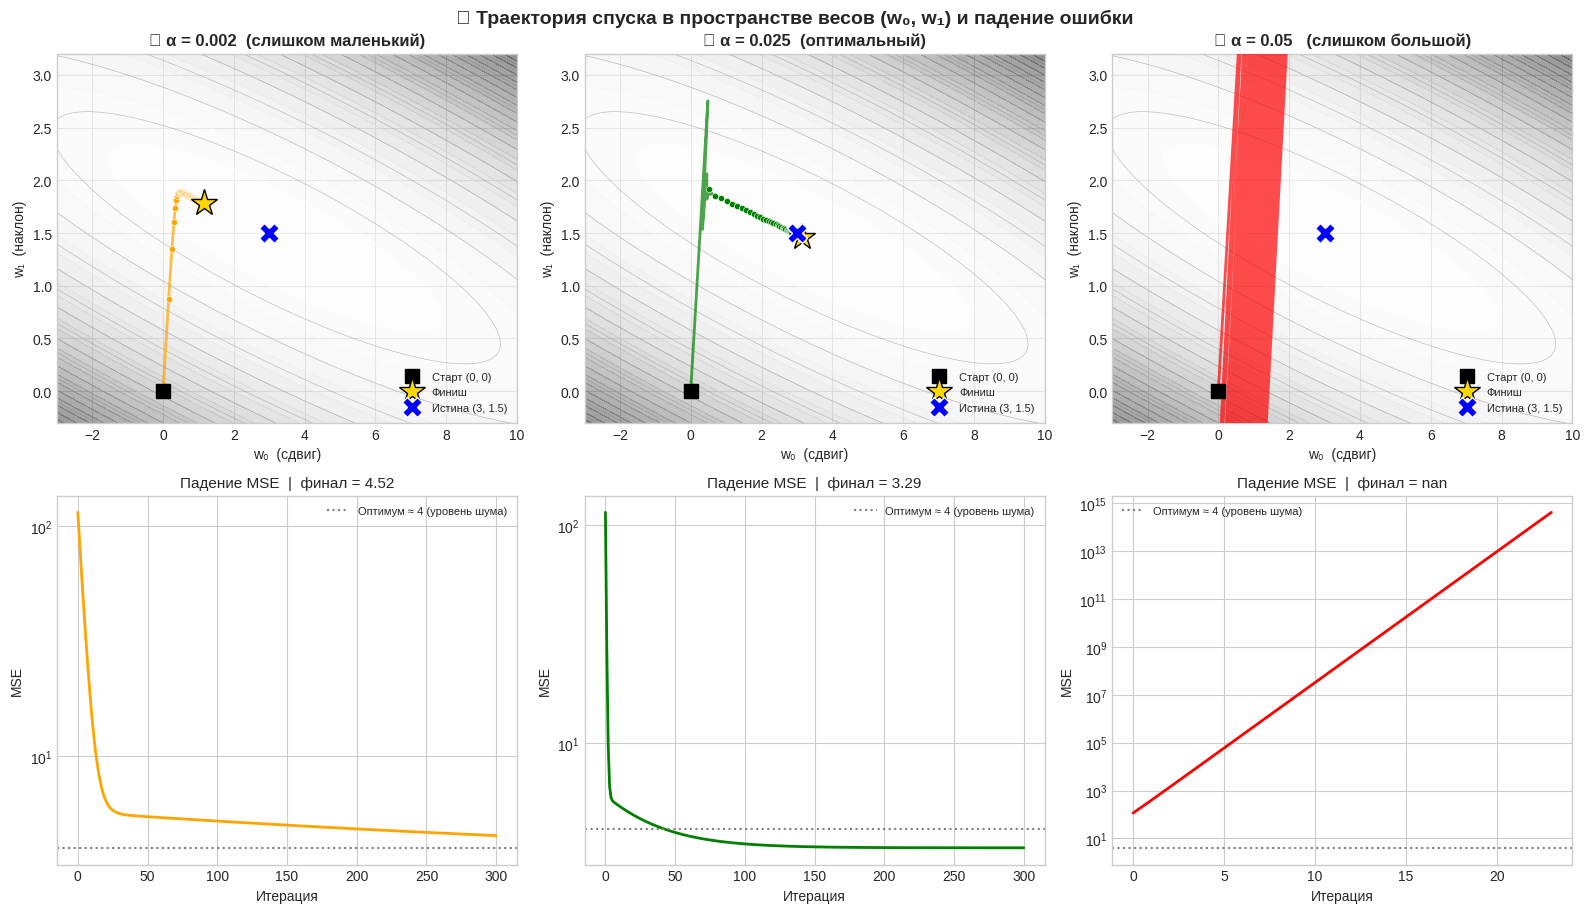


α       w₀ финал      w₁ финал      MSE финал     Расст. до (3,1.5)   Вердикт
------------------------------------------------------------------------------------------
0.002   1.142         1.785         4.52          1.880               🐌 не дошёл
0.025   3.154         1.462         3.29          0.159               ✅ хорошо
0.05    —             —             —             —                   🚀 разлетелся


In [64]:
# @title 🎬 Градиентный спуск: карта ландшафта + траектория
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

x = np.random.uniform(0, 10, 50)
y = 3 + 1.5 * x + np.random.normal(0, 2, 50)

def mse(w0, w1):
    return np.mean((y - (w0 + w1 * x)) ** 2)

def mse_grid(W0, W1, x, y):
    y_pred = W0[..., None] + W1[..., None] * x[None, None, :]
    return np.mean((y[None, None, :] - y_pred) ** 2, axis=-1)

def grads(w0, w1):
    err = y - (w0 + w1 * x)
    return -2 * np.mean(err), -2 * np.mean(err * x)

def run_gd(lr, n_iters):
    w0, w1 = 0.0, 0.0
    hist = [(w0, w1, mse(w0, w1))]
    for _ in range(n_iters):
        g0, g1 = grads(w0, w1)
        w0 -= lr * g0
        w1 -= lr * g1
        if not np.isfinite(w0) or abs(w0) > 1e6:   # защита от взрыва
            hist.append((np.nan, np.nan, np.nan))
            break
        hist.append((w0, w1, mse(w0, w1)))
    return np.array(hist)

# ---- Ключевое: α подобран под масштаб задачи ----
N_ITERS    = 300
hist_small = run_gd(0.002, N_ITERS)
hist_good  = run_gd(0.025, N_ITERS)
hist_big   = run_gd(0.05,  N_ITERS)

# --- Ландшафт ---
w0_grid = np.linspace(-5, 12, 120)
w1_grid = np.linspace(-0.5, 3.5, 120)
W0, W1 = np.meshgrid(w0_grid, w1_grid)
Z = mse_grid(W0, W1, x, y)
Z_vis = np.clip(Z, 0, 300)

# --- Рисуем ---
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

scenarios = [
    (hist_small, '🐌 α = 0.002  (слишком маленький)', 'orange'),
    (hist_good,  '✅ α = 0.025  (оптимальный)',        'green'),
    (hist_big,   '🚀 α = 0.05   (слишком большой)',    'red'),
]

for col, (hist, title, color) in enumerate(scenarios):
    # --- Верх: карта + траектория ---
    ax = axes[0, col]
    ax.contourf(W0, W1, Z_vis, levels=30, cmap='Greys', alpha=0.6)
    ax.contour(W0, W1, Z_vis, levels=20, colors='gray',
               linewidths=0.4, alpha=0.6)

    ax.plot(hist[:, 0], hist[:, 1], '-', color=color,
            linewidth=2, alpha=0.7, zorder=3)
    ax.scatter(hist[::5, 0], hist[::5, 1], color=color, s=20,
               edgecolor='white', linewidth=0.4, zorder=4)

    ax.plot(hist[0, 0], hist[0, 1], 's', color='black',
            markersize=10, label='Старт (0, 0)', zorder=6)
    ax.plot(hist[-1, 0], hist[-1, 1], '*', color='gold',
            markersize=20, markeredgecolor='black',
            label='Финиш', zorder=6)
    ax.plot(3, 1.5, 'X', color='blue', markersize=14,
            markeredgecolor='white', label='Истина (3, 1.5)', zorder=6)

    ax.set_xlabel('w₀  (сдвиг)')
    ax.set_ylabel('w₁  (наклон)')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlim(-3, 10); ax.set_ylim(-0.3, 3.2)
    ax.legend(fontsize=8, loc='lower right')

    # --- Низ: MSE по итерациям ---
    ax = axes[1, col]
    ax.plot(hist[:, 2], '-', color=color, linewidth=2)
    ax.axhline(4.0, color='gray', linestyle=':', linewidth=1.5,
               label='Оптимум ≈ 4 (уровень шума)')
    ax.set_xlabel('Итерация')
    ax.set_ylabel('MSE')
    ax.set_yscale('log')
    ax.set_title(f'Падение MSE  |  финал = {hist[-1, 2]:.2f}', fontsize=11)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.suptitle('🎯 Траектория спуска в пространстве весов (w₀, w₁) и падение ошибки',
             fontsize=14, fontweight='bold', y=1.01)
plt.show()

# --- Сводная таблица ---
print(f"\n{'α':<8}{'w₀ финал':<14}{'w₁ финал':<14}{'MSE финал':<14}{'Расст. до (3,1.5)':<20}{'Вердикт'}")
print('-' * 90)
for hist, a in [(hist_small, 0.002), (hist_good, 0.025), (hist_big, 0.05)]:
    w0_f, w1_f, m_f = hist[-1]
    if not np.isfinite(w0_f):
        print(f"{a:<8}{'—':<14}{'—':<14}{'—':<14}{'—':<20}🚀 разлетелся")
        continue
    dist = np.sqrt((w0_f - 3)**2 + (w1_f - 1.5)**2)
    if dist < 0.1:
        verdict = '✅ почти идеально'
    elif dist < 0.5:
        verdict = '✅ хорошо'
    elif dist < 2:
        verdict = '🐌 не дошёл'
    else:
        verdict = '❌ далеко'
    print(f"{a:<8}{w0_f:<14.3f}{w1_f:<14.3f}{m_f:<14.2f}{dist:<20.3f}{verdict}")

### 🔍 Что мы видим на графиках?

1. 🐌 **Слишком маленький $\alpha$ (0.001):** Модель делает крошечные шажки. Она **точно** идёт к минимуму, но ей нужно **тысячи итераций**, чтобы добраться. На практике это означает часы или дни обучения.
2. ✅ **Оптимальный $\alpha$ (0.01):** Золотая середина. Модель уверенно и быстро скатывается к минимуму за 20-30 шагов.
3. 🚀 **Слишком большой $\alpha$ (0.05):** Модель делает огромные прыжки. Она **перелетает** через минимум, попадает на противоположный склон, отскакивает обратно, и так до бесконечности. Loss не падает, а **взрывается**. Модель никогда не сойдётся.

> ⚠️ **Правило:** Если при обучении вы видите, что Loss на первой же эпохе становится `NaN` или растёт — **уменьшайте learning rate в 10 раз**.


#«Титрование дозы как Learning Rate» (Медицинская аналогия)
#Представьте, что вы подбираете дозу инсулина пациенту, чтобы достичь целевого уровня глюкозы. Как три сценария градиентного спуска соотносятся с вашими клиническими действиями по титрованию дозы? (Т.е по микродозе, огромную дозу и оптимальную дозу)


# 💥 Взрыв градиента: когда $\alpha$ слишком большой

> ⚠️ **Сценарий:** обучение на параболической функции потерь. Мы стартуем на крутом склоне, градиент большой.

## 🚀 Что происходит при гигантском $\alpha$

1. **Старт:** Мы находимся на склоне параболы. Склон крутой, градиент большой.
2. **Гигантский шаг:** Из-за огромного $\alpha$ модель делает гигантский прыжок. Она не просто доходит до дна — она **перелетает** через него.
3. **Приземление на противоположном склоне:** Модель приземляется на другой стороне параболы. Но из-за инерции прыжка она оказывается **выше**, чем была в начале!
4. **Ловушка:** Поскольку она теперь выше, склон в этой новой точке ещё круче, чем в предыдущей.
5. **Реакция модели:** Алгоритм честно вычисляет градиент. А так как склон круче, градиент получается ещё больше.
6. **Новый прыжок:** Модель умножает этот огромный градиент на огромный $\alpha$ и делает прыжок ещё в 2–3 раза длиннее, перелетая обратно на первую сторону, но ещё выше.
7. **Финал:** Амплитуда прыжков растёт лавинообразно. За 5–10 итераций веса улетают в значения типа $10^{38}$, компьютер сдаётся и выдаёт `NaN`.

## 🩺 Медицинская аналогия: титрование дозы как learning rate

Представьте, что вы подбираете дозу инсулина пациенту, чтобы достичь целевого уровня глюкозы.

- 🐌 **Микродоза ($\alpha$ слишком мал):** Уровень глюкозы меняется еле-еле. Вы движетесь в правильном направлении, но результат наступит очень нескоро. Нужны часы или дни титрования.
- ✅ **Оптимальная доза ($\alpha$ подобран):** Глюкоза плавно и быстро приближается к цели. Вы достигаете целевого диапазона за несколько шагов.
- 💥 **Гигантская доза ($\alpha$ слишком велик):** Вы вводите слишком много инсулина. Глюкоза падает ниже нормы — гипогликемия. Организм отвечает контррегуляцией, выбрасывает глюкозу, и уровень снова подскакивает **выше**, чем был. Затем вы снова вводите огромную дозу, и амплитуда скачков растёт. Это и есть **взрыв градиента**: система не сходится, а раскачивается всё сильнее, пока не выдаст `NaN`.

> ⚠️ **Правило:** Если loss на первых итерациях растёт или становится `NaN` — уменьшайте learning rate в 10 раз.

> 🧠 **Вывод:** Слишком большой $\alpha$ не ускоряет обучение, а **разрушает** его. Learning rate нужно титровать так же осторожно, как дозу сильного лекарства.



### 🎯 Зачем это всё знать врачу / биологу?

В `sklearn.linear_model.LinearRegression` уже всё написано действительно, действия делаются автоматически

Ответ прост: **без этого понимания вы не сможете отлаживать модели.**

Когда ваша модель:
- **Не сходится** (Loss растёт или застывает) → вы знаете, что виноват `learning rate`.
- **Застревает** на одном уровне → возможно, вы попали в **локальный минимум** (яму на склоне, которая не является самой глубокой точкой).

---

## 📝 Итоговый чек-лист занятия

За одну лекцию мы прошли путь от облака точек до работающего алгоритма. Запомните эту цепочку:

1. 📊 **Данные** → Облако точек в пространстве признаков.
2. 📏 **Модель** → Гипотеза (линия, плоскость, гиперплоскость): $y = w_0 + w_1x_1 + \dots$
3. ⚖️ **Функция потерь (Loss)** → Правило, как измерить «плохость» модели (MSE, MAE, Huber).
4. 🏔️ **Градиентный спуск** → Алгоритм, который ищет веса, минимизирующие Loss.
5. 🔍 **Интерпретация** → Анализ весов (с учётом размаха!)
6. 🔮 **Прогноз** → Применение модели к новым пациентам.


In [65]:
# @title 🎥 Анимация: линия и MSE падают вместе
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

x = np.random.uniform(0, 10, 50)
y = 3 + 1.5 * x + np.random.normal(0, 2, 50)

def compute_loss(w0, w1):
    return np.mean((y - (w0 + w1 * x))**2)

def compute_gradients(w0, w1):
    err = y - (w0 + w1 * x)
    return -2 * np.mean(err), -2 * np.mean(err * x)

# Запускаем GD, пишем историю
w0, w1 = 0.0, 0.0
lr = 0.01
hist = [(w0, w1, compute_loss(w0, w1))]
for _ in range(60):
    g0, g1 = compute_gradients(w0, w1)
    w0 -= lr * g0
    w1 -= lr * g1
    hist.append((w0, w1, compute_loss(w0, w1)))
hist = np.array(hist)

# Рисуем два окна
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
x_line = np.array([0, 10])

def frame(i):
    ax1.clear(); ax2.clear()

    w0_i, w1_i, loss_i = hist[i]

    # ЛЕВО: облако + текущая линия
    ax1.scatter(x, y, color='teal', alpha=0.5, s=30,
                edgecolor='black', linewidth=0.3)
    ax1.plot(x_line, 3 + 1.5 * x_line, color='gray',
             linewidth=1.5, linestyle=':')
    ax1.plot(x_line, w0_i + w1_i * x_line, color='#ef553b', linewidth=3)
    ax1.set_title(f'Итерация {i} | w₀={w0_i:.2f}, w₁={w1_i:.2f}',
                  fontsize=12, fontweight='bold')
    ax1.set_xlabel('x'); ax1.set_ylabel('y')
    ax1.set_ylim(-5, 25)

    # ПРАВО: падение MSE (график по итерациям)
    ax2.plot(hist[:i+1, 2], color='#636efa', linewidth=2.5)
    ax2.scatter([i], [loss_i], color='#ef553b', s=80, zorder=5,
                edgecolor='black')
    ax2.set_title(f'MSE = {loss_i:.2f}', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Итерация'); ax2.set_ylabel('MSE')
    ax2.set_xlim(0, len(hist))
    ax2.set_ylim(0, hist[:, 2].max() * 1.05)

anim = FuncAnimation(fig, frame, frames=len(hist), interval=150, repeat=False)
plt.close(fig)
HTML(anim.to_jshtml())

Output hidden; open in https://colab.research.google.com to view.

In [66]:
# @title 🎬 Плохой α vs хороший α: линия + MSE параллельно
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

# --- Данные ---
x = np.random.uniform(0, 10, 50)
y = 3 + 1.5 * x + np.random.normal(0, 2, 50)
x_line = np.array([0, 10])

def compute_loss(w0, w1):
    return np.mean((y - (w0 + w1 * x)) ** 2)

def compute_gradients(w0, w1):
    err = y - (w0 + w1 * x)
    return -2 * np.mean(err), -2 * np.mean(err * x)

def run_gd(lr, n_iter=25, w0=0.0, w1=0.0):
    hist = [(w0, w1, compute_loss(w0, w1))]
    for _ in range(n_iter):
        g0, g1 = compute_gradients(w0, w1)
        w0 -= lr * g0
        w1 -= lr * g1
        loss = compute_loss(w0, w1)
        if not np.isfinite(loss) or abs(w0) > 1e6 or abs(w1) > 1e6:
            hist.append((np.nan, np.nan, np.nan))
            break
        hist.append((w0, w1, loss))
    # добить до конца
    while len(hist) < n_iter + 1:
        hist.append((np.nan, np.nan, np.nan))
    return np.array(hist)

N_ITER = 25
hist_bad  = run_gd(0.10, N_ITER)   # взрыв
hist_good = run_gd(0.02, N_ITER)   # сходимость

# ---------- Рисуем 2x2 ----------
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

ax_line_bad  = axes[0, 0]
ax_line_good = axes[0, 1]
ax_mse_bad   = axes[1, 0]
ax_mse_good  = axes[1, 1]

# --- Общие настройки для графиков линии ---
for ax, title in [(ax_line_bad,  '🚀 α = 0.10  (взрыв)'),
                  (ax_line_good, '✅ α = 0.02  (сходимость)')]:
    ax.scatter(x, y, color='teal', alpha=0.45, s=28,
               edgecolor='black', linewidth=0.3, zorder=2)
    ax.plot(x_line, 3 + 1.5 * x_line, color='gray', linewidth=1.4,
            linestyle=':', label='Истина', zorder=3)
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.set_ylim(-10, 30)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(fontsize=9, loc='upper left')

# линия гипотезы (пустая — будем обновлять)
line_bad,  = ax_line_bad.plot([], [], color='#ef553b', linewidth=3, zorder=4)
line_good, = ax_line_good.plot([], [], color='#00b050', linewidth=3, zorder=4)

# подписи w0, w1
txt_bad  = ax_line_bad.text(0.98, 0.05, '', transform=ax_line_bad.transAxes,
                            ha='right', va='bottom', fontsize=10,
                            family='monospace',
                            bbox=dict(boxstyle='round', facecolor='white',
                                      edgecolor='#ef553b', alpha=0.9))
txt_good = ax_line_good.text(0.98, 0.05, '', transform=ax_line_good.transAxes,
                             ha='right', va='bottom', fontsize=10,
                             family='monospace',
                             bbox=dict(boxstyle='round', facecolor='white',
                                       edgecolor='#00b050', alpha=0.9))

# --- Общие настройки для графиков MSE ---
mse_ymax = 500
for ax, title, color in [(ax_mse_bad,  '💥 MSE при α = 0.10', '#ef553b'),
                         (ax_mse_good, '📉 MSE при α = 0.02', '#00b050')]:
    ax.set_xlim(0, N_ITER)
    ax.set_ylim(0, mse_ymax)
    ax.set_xlabel('Итерация'); ax.set_ylabel('MSE')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.axhline(4.0, color='gray', linestyle=':', linewidth=1.5)
    ax.text(N_ITER * 0.98, 8, 'уровень шума ≈ 4',
            ha='right', fontsize=9, color='gray')

curve_bad,  = ax_mse_bad.plot([], [],  color='#ef553b', linewidth=2.5)
dot_bad,    = ax_mse_bad.plot([], [], 'o', color='#ef553b', markersize=9,
                              markeredgecolor='black', zorder=5)
curve_good, = ax_mse_good.plot([], [], color='#00b050', linewidth=2.5)
dot_good,   = ax_mse_good.plot([], [], 'o', color='#00b050', markersize=9,
                               markeredgecolor='black', zorder=5)

label_bad  = ax_mse_bad.text(0.02, 0.92, '', transform=ax_mse_bad.transAxes,
                             fontsize=12, fontweight='bold', color='#ef553b')
label_good = ax_mse_good.text(0.02, 0.92, '', transform=ax_mse_good.transAxes,
                              fontsize=12, fontweight='bold', color='#00b050')

def frame(i):
    # --- ЛИНИЯ: плохой ---
    w0_b, w1_b, _ = hist_bad[i]
    if np.isfinite(w0_b) and abs(w1_b) < 100:
        line_bad.set_data(x_line, w0_b + w1_b * x_line)
        txt_bad.set_text(f'w₀={w0_b:6.1f}  w₁={w1_b:6.1f}')
    else:
        line_bad.set_data([], [])
        txt_bad.set_text('💥 взрыв — веса NaN')

    # --- ЛИНИЯ: хороший ---
    w0_g, w1_g, _ = hist_good[i]
    line_good.set_data(x_line, w0_g + w1_g * x_line)
    txt_good.set_text(f'w₀={w0_g:6.2f}  w₁={w1_g:6.2f}')

    # --- MSE: плохой ---
    curve_bad.set_data(range(i + 1), np.clip(hist_bad[:i + 1, 2], 0, mse_ymax))
    if np.isfinite(hist_bad[i, 2]):
        dot_bad.set_data([i], [min(hist_bad[i, 2], mse_ymax)])
        label_bad.set_text(f'MSE = {hist_bad[i, 2]:.1f}')
    else:
        dot_bad.set_data([], [])
        label_bad.set_text('💥 MSE = NaN')

    # --- MSE: хороший ---
    curve_good.set_data(range(i + 1), hist_good[:i + 1, 2])
    dot_good.set_data([i], [hist_good[i, 2]])
    label_good.set_text(f'MSE = {hist_good[i, 2]:.2f}')

    return (line_bad, line_good, txt_bad, txt_good,
            curve_bad, dot_bad, curve_good, dot_good,
            label_bad, label_good)

anim = FuncAnimation(fig, frame, frames=N_ITER + 1,
                     interval=300, repeat=False, blit=False)

plt.tight_layout()
plt.close(fig)
HTML(anim.to_jshtml())

Output hidden; open in https://colab.research.google.com to view.

In [67]:
# @title 🎬 Анимация: плохой α vs хороший α
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

# ---------- Данные ----------
n, p = 200, 5
X_raw = np.random.randn(n, p)
w_true = np.array([2.0, -1.0, 3.0, 0.5, -2.0])
y = X_raw @ w_true + 1.0 + np.random.randn(n) * 0.5

# Стандартизация + столбец для bias
X = (X_raw - X_raw.mean(0)) / X_raw.std(0)
X = np.hstack([np.ones((n, 1)), X])

def mse(w):  return np.mean((y - X @ w) ** 2)
def grad(w): return -2/n * X.T @ (y - X @ w)

def run_gd(lr, n_iter):
    w = np.zeros(X.shape[1])
    hist = [mse(w)]
    for _ in range(n_iter):
        w = w - lr * grad(w)
        loss = mse(w)
        if not np.isfinite(loss) or loss > 1e10:
            hist.append(np.nan)
            break
        hist.append(loss)
    # добить NaN до конца, если взорвалось
    while len(hist) < n_iter + 1:
        hist.append(np.nan)
    return np.array(hist)

N_ITER = 40
hist_bad  = run_gd(0.9, N_ITER)   # плохой — дёргается / взрывается
hist_good = run_gd(0.1, N_ITER)   # хороший — плавно сходится

# Единая шкала по Y, чтобы контраст был честным
y_max = np.nanmax([np.nanmax(hist_bad), np.nanmax(hist_good)]) * 1.1

# ---------- Рисуем ----------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)

for ax, hist, color, title in [
    (ax1, hist_bad,  '#ef553b', '🚀 α = 0.9   (слишком большой)'),
    (ax2, hist_good, '#00b050', '✅ α = 0.1   (хороший)'),
]:
    ax.set_yscale('log')
    ax.set_xlim(0, N_ITER)
    ax.set_ylim(0.2, y_max)
    ax.set_xlabel('Итерация', fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.grid(alpha=0.3, which='both')
ax1.set_ylabel('MSE (лог. шкала)', fontsize=12)

# Заранее нарисуем «уровень шума», к которому должна прийти модель
for ax in (ax1, ax2):
    ax.axhline(0.25, color='gray', linestyle=':', linewidth=1.5)
    ax.text(N_ITER * 0.98, 0.28, 'уровень шума',
            ha='right', va='bottom', fontsize=9, color='gray')

line_bad,  = ax1.plot([], [], '-',  color='#ef553b', linewidth=2.5)
dot_bad,   = ax1.plot([], [], 'o',  color='#ef553b', markersize=10,
                      markeredgecolor='black')
line_good, = ax2.plot([], [], '-',  color='#00b050', linewidth=2.5)
dot_good,  = ax2.plot([], [], 'o',  color='#00b050', markersize=10,
                      markeredgecolor='black')

label_bad  = ax1.text(0.02, 0.95, '', transform=ax1.transAxes,
                      fontsize=11, fontweight='bold', color='#ef553b')
label_good = ax2.text(0.02, 0.95, '', transform=ax2.transAxes,
                      fontsize=11, fontweight='bold', color='#00b050')

def frame(i):
    # плохая кривая
    line_bad.set_data(range(i + 1), hist_bad[:i + 1])
    if np.isfinite(hist_bad[i]):
        dot_bad.set_data([i], [hist_bad[i]])
        label_bad.set_text(f'MSE = {hist_bad[i]:.2e}')
    else:
        dot_bad.set_data([], [])
        label_bad.set_text('💥 ВЗРЫВ (NaN)')

    # хорошая кривая
    line_good.set_data(range(i + 1), hist_good[:i + 1])
    dot_good.set_data([i], [hist_good[i]])
    label_good.set_text(f'MSE = {hist_good[i]:.3f}')

    return line_bad, dot_bad, line_good, dot_good, label_bad, label_good

anim = FuncAnimation(fig, frame, frames=N_ITER + 1,
                     interval=250, repeat=False, blit=False)

plt.tight_layout()
plt.close(fig)
HTML(anim.to_jshtml())

Output hidden; open in https://colab.research.google.com to view.

#🔬 Как на практике подбирают Learning Rate?

#Метод 1: Learning Rate Finder (Поиск оптимального α)
Мы запускаем модель с очень маленьким learning rate и постепенно увеличиваем его, наблюдая, как меняется Loss.

Идея: Находим точку, где Loss начинает быстро падать, но ещё не взрывается.

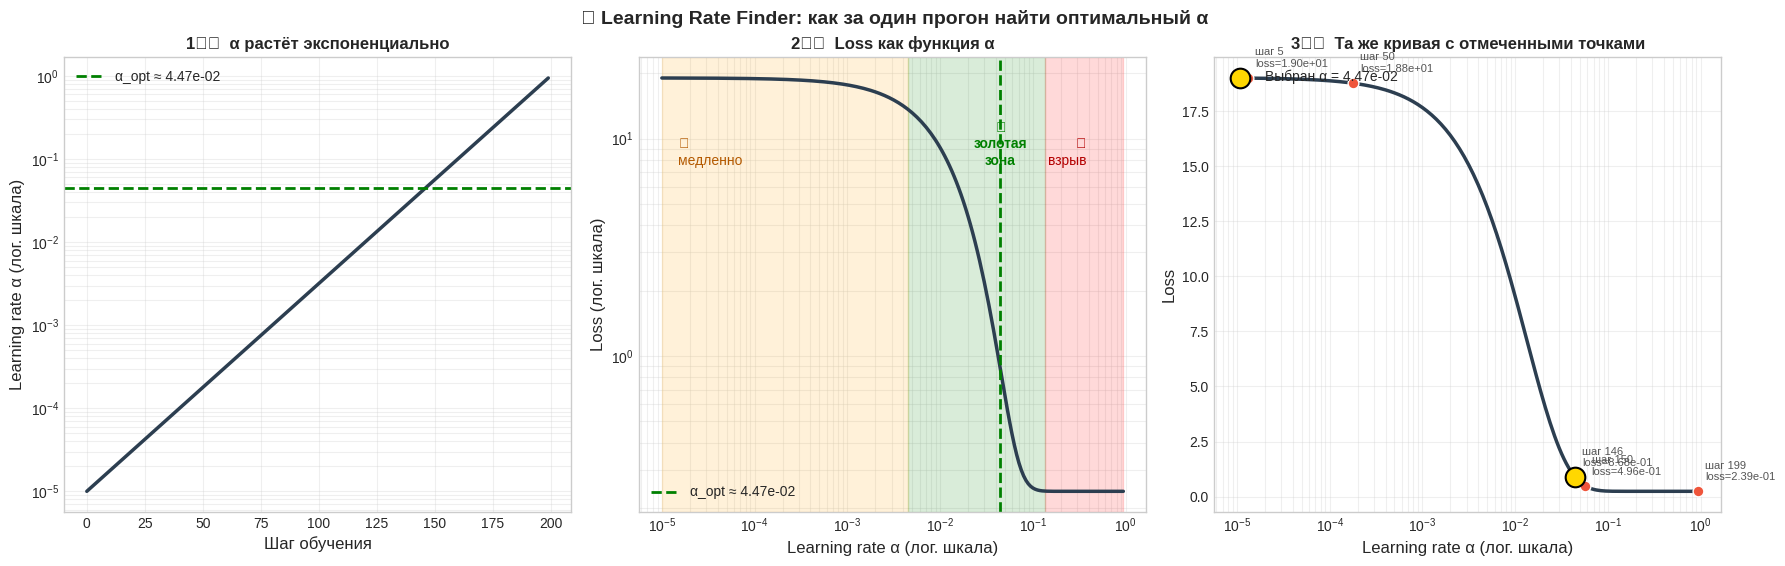

Стартовый α:        1.00e-05
Финальный α:        9.44e-01
Всего шагов:        200

🎯 Найденный α_opt: 4.467e-02
   (самая крутая точка падения Loss на лог-лог графике)

Рабочая зона:
   от 4.47e-03  до  1.34e-01


In [68]:
# @title 🔬 Learning Rate Finder: пошаговая визуализация
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

# ---------- Данные ----------
n, p = 300, 5
X_raw = np.random.randn(n, p)
w_true = np.array([2.0, -1.0, 3.0, 0.5, -2.0])
y = X_raw @ w_true + 1.0 + np.random.randn(n) * 0.5

# Стандартизация + bias
X = (X_raw - X_raw.mean(0)) / X_raw.std(0)
X = np.hstack([np.ones((n, 1)), X])

def mse(w):  return np.mean((y - X @ w) ** 2)
def grad(w): return -2/n * X.T @ (y - X @ w)

# ---------- LR Range Test ----------
# Идея: стартуем с крошечного α, на каждом шаге умножаем на q.
# Это даёт равномерный рост по лог-шкале.
lr_min, lr_max = 1e-5, 1.0
n_steps = 200
q = (lr_max / lr_min) ** (1 / n_steps)   # коэффициент роста за шаг

w = np.zeros(X.shape[1])
lrs, losses = [], []
best_loss = np.inf

for step in range(n_steps):
    lr = lr_min * (q ** step)
    w = w - lr * grad(w)
    loss = mse(w)

    lrs.append(lr)
    losses.append(loss)

    # Досрочный стоп: loss вырос в 4 раза от лучшего
    if loss < best_loss:
        best_loss = loss
    if loss > 4 * best_loss:
        break

lrs    = np.array(lrs)
losses = np.array(losses)

# ---------- Находим "золотую зону" ----------
# Классический критерий (Leslie Smith):
# α_opt = точка, где кривая Loss имеет минимальный наклон (быстрее всего падает).
# На лог-шкале α это соответствует минимуму производной d(log Loss)/d(log α).
log_lr    = np.log10(lrs)
log_loss  = np.log10(losses)
slopes    = np.gradient(log_loss, log_lr)
# Сглаживаем, чтобы убрать шум
kernel = np.ones(5) / 5
slopes_smooth = np.convolve(slopes, kernel, mode='same')
i_opt = np.argmin(slopes_smooth)          # самая крутая точка падения
lr_opt = lrs[i_opt]

# Границы зон
left_edge  = lr_opt / 10
right_edge = lr_opt * 3

# ---------- РИСУЕМ: три панели ----------
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# ======== ПАНЕЛЬ 1: как α растёт во времени ========
ax = axes[0]
ax.semilogy(range(len(lrs)), lrs, color='#2c3e50', linewidth=2.5)
ax.axhline(lr_opt, color='green', linestyle='--', linewidth=2,
           label=f'α_opt ≈ {lr_opt:.2e}')
ax.set_xlabel('Шаг обучения', fontsize=12)
ax.set_ylabel('Learning rate α (лог. шкала)', fontsize=12)
ax.set_title('1️⃣  α растёт экспоненциально',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3, which='both')

# ======== ПАНЕЛЬ 2: Loss vs α (тот самый график LR Finder) ========
ax = axes[1]
ax.loglog(lrs, losses, color='#2c3e50', linewidth=2.5)

ax.axvspan(lrs.min(),  left_edge,  color='orange', alpha=0.15)
ax.axvspan(left_edge,  right_edge, color='green',  alpha=0.15)
ax.axvspan(right_edge, lrs.max(),  color='red',    alpha=0.15)

ax.axvline(lr_opt, color='green', linestyle='--', linewidth=2,
           label=f'α_opt ≈ {lr_opt:.2e}')

# Текстовые подписи зон
ax.text(lrs.min()*1.5, losses.max()*0.4, '🐌\nмедленно',
        fontsize=10, ha='left', color='#b35900')
ax.text(lr_opt, losses.max()*0.4, '✅\nзолотая\nзона',
        fontsize=10, ha='center', color='green', fontweight='bold')
ax.text(lrs.max()*0.4, losses.max()*0.4, '💥\nвзрыв',
        fontsize=10, ha='right', color='#b30000')

ax.set_xlabel('Learning rate α (лог. шкала)', fontsize=12)
ax.set_ylabel('Loss (лог. шкала)', fontsize=12)
ax.set_title('2️⃣  Loss как функция α',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10, loc='lower left')
ax.grid(alpha=0.3, which='both')

# ======== ПАНЕЛЬ 3: та же кривая, но с отмеченными точками ========
ax = axes[2]
ax.semilogx(lrs, losses, color='#2c3e50', linewidth=2.5, zorder=2)

# Точка, которую выбрал алгоритм
ax.scatter([lr_opt], [losses[i_opt]], color='gold', s=200,
           edgecolor='black', linewidth=1.5, zorder=5,
           label=f'Выбран α = {lr_opt:.2e}')

# Несколько «показательных» точек
show_idx = [5, len(lrs)//4, i_opt, 3*len(lrs)//4, len(lrs)-1]
for idx in show_idx:
    ax.scatter([lrs[idx]], [losses[idx]], color='#ef553b',
               s=60, edgecolor='white', linewidth=1, zorder=4)
    ax.annotate(f'шаг {idx}\nloss={losses[idx]:.2e}',
                xy=(lrs[idx], losses[idx]),
                xytext=(5, 8), textcoords='offset points',
                fontsize=8, color='#555')

ax.set_xlabel('Learning rate α (лог. шкала)', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('3️⃣  Та же кривая с отмеченными точками',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')
ax.grid(alpha=0.3, which='both')

plt.tight_layout()
plt.suptitle('🔬 Learning Rate Finder: как за один прогон найти оптимальный α',
             fontsize=14, fontweight='bold', y=1.02)
plt.show()

# ---------- Текстовый вывод ----------
print(f"Стартовый α:        {lrs[0]:.2e}")
print(f"Финальный α:        {lrs[-1]:.2e}")
print(f"Всего шагов:        {len(lrs)}")
print()
print(f"🎯 Найденный α_opt: {lr_opt:.3e}")
print(f"   (самая крутая точка падения Loss на лог-лог графике)")
print()
print(f"Рабочая зона:")
print(f"   от {left_edge:.2e}  до  {right_edge:.2e}")

# 🔬 Метод 2: Cyclical Learning Rates — «качели» вместо одной скорости

## 🤔 В чём слабость Метода 1

LR Finder даёт одно число — `α_opt`. Но с постоянным `α` есть скрытая ловушка: модель может **застрять на «плато»** — плоском участке ландшафта, где градиент почти нулевой. Оттуда не выбраться: шагов не хватает, чтобы перескочить.

## 💡 Идея Лесли Смита: «качели»

А что если **не фиксировать α**, а циклически менять его между двумя границами — `α_min` и `α_max`?

- 📈 **Разгон** (большой α): модель набирает скорость и **выпрыгивает из мелких ям**.
- 📉 **Торможение** (маленький α): модель **аккуратно оседает** на дно ближайшего минимума.

Так модель «прощупывает» ландшафт: не залипает в одном месте, но и не разлетается.

## 📐 Треугольная политика

Простейшая форма — линейный треугольник: `α` растёт от `α_min` до `α_max`, потом падает обратно. Цикл повторяется.

$$\alpha(k) = \alpha_{\min} + (\alpha_{\max} - \alpha_{\min}) \cdot \max\!\left(0,\; 1 - \left|\tfrac{k}{s} - 2\cdot\text{cycle} - 1\right|\right)$$

где `s = step_size` — половина длины цикла.

> 🧩 **Ключ:** границы `α_min` и `α_max` берём прямо из LR Finder. Поэтому **метод 1 и метод 2 работают в паре**.

## 🎨 Что на трёх панелях

1. **Слева** — «пила» α. Красные зоны = разгон, синие = торможение. Красная пунктирная — постоянный `α = 0.01` для сравнения.
2. **В центре** — Loss. Красная кривая (постоянный α) выходит на плато и стоит. Синяя (CLR) на каждом пике **дожимает ошибку ещё ниже**.
3. **Справа** — траектория в пространстве весов, раскрашенная по α: **красный = большой шаг, синий = маленький**.

## 🎯 Главное

| | Метод 1 (LR Finder) | Метод 2 (CLR) |
|---|---|---|
| Что даёт | одно число `α_opt` | диапазон `[α_min, α_max]` |
| Как используется | постоянно | «качели» |
| Проблема | застревает на плато | — |
| Связь | находит границы | использует их |

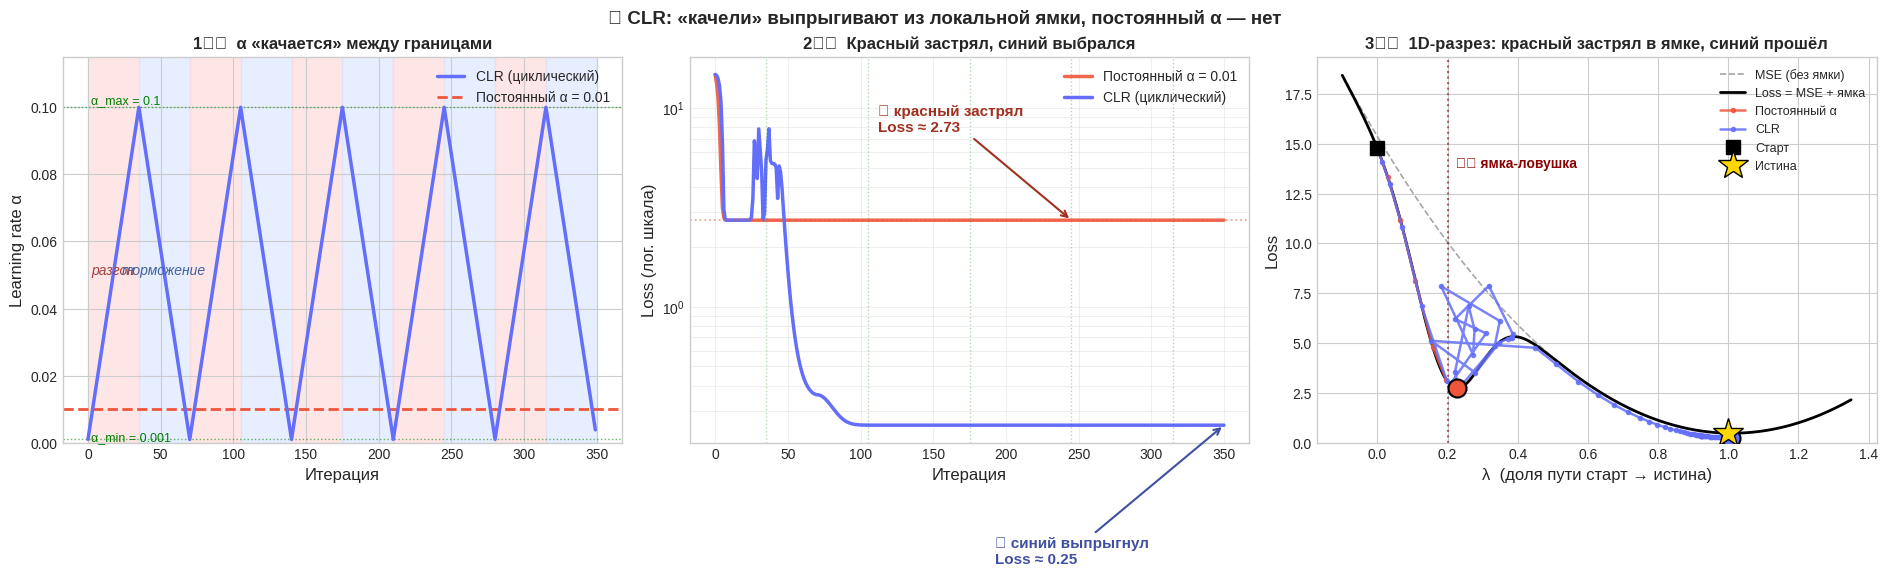

📊 СРАВНЕНИЕ:
  Постоянный α = 0.01:  финальный Loss = 2.727   (λ = 0.228)
  CLR (циклический):    финальный Loss = 0.253   (λ = 1.008)
  Разница:              × 10.8 раз

  Центр ямки:  λ = 0.2, ||C|| = 0.775
  Глубина:     7.0,  σ = 0.35
  α_min = 0.001,  α_max = 0.1,  полуцикл = 35


In [70]:
# @title 🔬 Метод 2: CLR — «качели» выпрыгивают из ЛОВУШКИ (в 1D-разрезе видно)
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

# ---------- Данные ----------
n, p = 200, 3
X_raw = np.random.randn(n, p)
w_true = np.array([2.0, -1.0, 3.0])
y = X_raw @ w_true + 1.0 + np.random.randn(n) * 0.5
X = (X_raw - X_raw.mean(0)) / X_raw.std(0)
X = np.hstack([np.ones((n, 1)), X])

# Полный вектор истины: [intercept, 2, -1, 3]
W_TRUE = np.array([1.0, 2.0, -1.0, 3.0])
DIR    = W_TRUE / np.linalg.norm(W_TRUE)     # единичное направление старт → истина

# ---------- ЛОВУШКА: гауссова ямка на 20% пути к истине ----------
LAMBDA_C   = 0.20                            # доля пути до центра ямки
CENTER     = LAMBDA_C * W_TRUE               # 4D-центр ямки
TRAP_DEPTH = 7.0                             # насколько глубоко «проседает» Loss
TRAP_SIGMA = 0.35                            # радиус ямки

def mse(w):  return np.mean((y - X @ w) ** 2)

def trap(w):
    d = w - CENTER
    return -TRAP_DEPTH * np.exp(-np.sum(d * d) / (2 * TRAP_SIGMA ** 2))

def loss(w): return mse(w) + trap(w)

def grad(w):
    g = -2 / n * X.T @ (y - X @ w)
    d = w - CENTER
    e = np.exp(-np.sum(d * d) / (2 * TRAP_SIGMA ** 2))
    g += TRAP_DEPTH * e * d / TRAP_SIGMA ** 2
    return g

def lam(w):
    """Проекция w на прямую старт→истина (безразмерная доля пути)."""
    return float(np.dot(w, W_TRUE) / np.dot(W_TRUE, W_TRUE))

# ---------- Треугольный CLR ----------
def triangular_clr(base_lr, max_lr, step_size, n_iter):
    lrs = []
    for k in range(n_iter):
        cycle = np.floor(1 + k / (2 * step_size))
        x = np.abs(k / step_size - 2 * cycle + 1)
        lrs.append(base_lr + (max_lr - base_lr) * max(0, 1 - x))
    return np.array(lrs)

# ---------- Обучение ----------
def run_gd(schedule):
    w = np.zeros(X.shape[1])
    losses, traj = [loss(w)], [w.copy()]
    for lr in schedule:
        w = w - lr * grad(w)
        L = loss(w)
        losses.append(L); traj.append(w.copy())
        if not np.isfinite(L) or L > 1e8: break
    return np.array(losses), np.array(traj)

def run_gd_const(lr, n_iter):
    return run_gd(np.full(n_iter, lr))

# ---------- Параметры ----------
N_ITER     = 350
base_lr    = 0.001
max_lr     = 0.10
step_size  = 35
ALPHA_CONST = 0.01

schedule_clr = triangular_clr(base_lr, max_lr, step_size, N_ITER)
losses_clr, traj_clr = run_gd(schedule_clr)
losses_const, traj_red = run_gd_const(ALPHA_CONST, N_ITER)

# 1D-ландшафт вдоль прямой старт → истина
lam_grid = np.linspace(-0.1, 1.35, 400)
loss_1d  = np.array([loss(lam * W_TRUE) for lam in lam_grid])
mse_1d   = np.array([mse(lam * W_TRUE)  for lam in lam_grid])

# Траектории в координатах (λ, Loss)
def to_lambda(path):
    return np.array([lam(w) for w in path])
def to_loss(path):
    return np.array([loss(w) for w in path])

lam_red, L_red = to_lambda(traj_red), to_loss(traj_red)
lam_clr, L_clr = to_lambda(traj_clr), to_loss(traj_clr)

# ---------- Рисуем ----------
fig, axes = plt.subplots(1, 3, figsize=(19, 5.8))
iters = np.arange(N_ITER)

# ===== Панель 1: расписание α =====
ax = axes[0]
for k in range(0, N_ITER, step_size):
    end = min(k + step_size, N_ITER)
    color = '#ffd6d6' if (k // step_size) % 2 == 0 else '#d6e4ff'
    ax.axvspan(k, end, color=color, alpha=0.6, zorder=0)
ax.plot(iters, schedule_clr, color='#636efa', linewidth=2.5,
        label='CLR (циклический)', zorder=3)
ax.axhline(ALPHA_CONST, color='#ef553b', linewidth=2, linestyle='--',
           label=f'Постоянный α = {ALPHA_CONST}', zorder=2)
ax.axhline(max_lr, color='green', linewidth=1, linestyle=':', alpha=0.6)
ax.axhline(base_lr, color='green', linewidth=1, linestyle=':', alpha=0.6)
ax.text(2, max_lr*1.01, f'α_max = {max_lr}', fontsize=9, color='green')
ax.text(2, base_lr*0.6, f'α_min = {base_lr}', fontsize=9, color='green')
ax.text(step_size/2,   max_lr*0.5, 'разгон',     ha='center',
        fontsize=10, color='#a04040', style='italic')
ax.text(step_size*1.5, max_lr*0.5, 'торможение', ha='center',
        fontsize=10, color='#4060a0', style='italic')
ax.set_xlabel('Итерация', fontsize=12)
ax.set_ylabel('Learning rate α', fontsize=12)
ax.set_title('1️⃣  α «качается» между границами', fontsize=12, fontweight='bold')
ax.legend(fontsize=10, loc='upper right')
ax.set_ylim(0, max_lr * 1.15)

# ===== Панель 2: Loss во времени =====
ax = axes[1]
ax.semilogy(losses_const, color='#ef553b', linewidth=2.5,
            label=f'Постоянный α = {ALPHA_CONST}', alpha=0.9)
ax.semilogy(losses_clr, color='#636efa', linewidth=2.5,
            label='CLR (циклический)')
plateau_val = np.nanmedian(losses_const[-100:])
ax.axhline(plateau_val, color='#ef553b', linestyle=':', alpha=0.55, linewidth=1.3)
ax.annotate(f'🔒 красный застрял\nLoss ≈ {plateau_val:.2f}',
            xy=(N_ITER*0.7, plateau_val),
            xytext=(N_ITER*0.32, plateau_val*2.8),
            fontsize=11, color='#a03020', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#a03020', lw=1.5))
ax.annotate(f'✅ синий выпрыгнул\nLoss ≈ {losses_clr[-1]:.2f}',
            xy=(N_ITER, losses_clr[-1]),
            xytext=(N_ITER*0.55, losses_clr[-1]*0.2),
            fontsize=11, color='#4050a0', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#4050a0', lw=1.5))
for k in range(step_size, N_ITER, 2 * step_size):
    ax.axvline(k, color='green', linestyle=':', alpha=0.3, linewidth=1)
ax.set_xlabel('Итерация', fontsize=12)
ax.set_ylabel('Loss (лог. шкала)', fontsize=12)
ax.set_title('2️⃣  Красный застрял, синий выбрался',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10, loc='upper right')
ax.grid(alpha=0.3, which='both')

# ===== Панель 3: 1D-ландшафт вдоль прямой старт → истина =====
ax = axes[2]
ax.plot(lam_grid, mse_1d,  color='gray', linewidth=1.2, linestyle='--',
        alpha=0.7, label='MSE (без ямки)')
ax.plot(lam_grid, loss_1d, color='black', linewidth=2.0,
        label='Loss = MSE + ямка')
# Сама ямка
ax.axvline(LAMBDA_C, color='#8B0000', linestyle=':', alpha=0.6, linewidth=1.5)
ax.text(LAMBDA_C, np.max(loss_1d)*0.75, '  🕳️ ямка-ловушка',
        fontsize=10, color='#8B0000', fontweight='bold')

# Красный путь по ландшафту
ax.plot(lam_red, L_red, '-o', color='#ef553b', linewidth=1.8,
        markersize=3, alpha=0.85, label='Постоянный α', zorder=5)
ax.plot(lam_red[-1], L_red[-1], 'o', color='#ef553b',
        markersize=13, markeredgecolor='black', markeredgewidth=1.5, zorder=7)

# Синий путь
ax.plot(lam_clr, L_clr, '-o', color='#636efa', linewidth=1.8,
        markersize=3, alpha=0.85, label='CLR', zorder=5)
ax.plot(lam_clr[-1], L_clr[-1], 'o', color='#636efa',
        markersize=13, markeredgecolor='black', markeredgewidth=1.5, zorder=7)

# Старт и истина
ax.plot(0, loss(np.zeros(4)), 's', color='black',
        markersize=10, label='Старт', zorder=8)
ax.plot(1.0, loss(W_TRUE), '*', color='gold', markersize=22,
        markeredgecolor='black', label='Истина', zorder=8)

ax.set_xlabel('λ  (доля пути старт → истина)', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('3️⃣  1D-разрез: красный застрял в ямке, синий прошёл',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
ax.set_ylim(0, np.max(loss_1d) * 1.05)

plt.tight_layout()
plt.suptitle('🔬 CLR: «качели» выпрыгивают из локальной ямки, постоянный α — нет',
             fontsize=13.5, fontweight='bold', y=1.02)
plt.show()

# ---------- Численный итог ----------
print("📊 СРАВНЕНИЕ:")
print(f"  Постоянный α = {ALPHA_CONST}:  финальный Loss = {losses_const[-1]:.3f}"
      f"   (λ = {lam(traj_red[-1]):.3f})")
print(f"  CLR (циклический):    финальный Loss = {losses_clr[-1]:.3f}"
      f"   (λ = {lam(traj_clr[-1]):.3f})")
print(f"  Разница:              × {losses_const[-1]/losses_clr[-1]:.1f} раз")
print()
print(f"  Центр ямки:  λ = {LAMBDA_C}, ||C|| = {np.linalg.norm(CENTER):.3f}")
print(f"  Глубина:     {TRAP_DEPTH},  σ = {TRAP_SIGMA}")
print(f"  α_min = {base_lr},  α_max = {max_lr},  полуцикл = {step_size}")